# 📊 Notebook 01 — Exploratory Data Analysis & Data Quality Audit
## SentimentCompass: Understanding User Satisfaction, Topic Trends, and Migration Signals
### Across ChatGPT, Gemini, Claude, Microsoft Copilot, and Perplexity

---

**Project:** SentimentCompass  
**Dataset:** The Generative AI Ecosystem — 50,000 User Reviews (2026)  
**Notebook purpose:** Comprehensive EDA to understand dataset structure, quality, and statistical properties before any NLP modelling is performed.

### 📋 Table of Contents

| # | Section | Figures |
|---|---------|---------|
| 1 | Setup & Configuration | — |
| 2 | Load Dataset | — |
| 3 | Dataset Overview | — |
| 4 | Data Quality Audit | `fig_01` |
| 5 | Univariate Analysis | `fig_02` → `fig_09` |
| 6 | Bivariate Analysis | `fig_10` → `fig_13` |
| 7 | Numerical Correlation Matrix | `fig_14` |
| 8 | EDA Summary & Key Findings | — |

> 📁 All 14 figures are automatically saved to `../outputs/figures/` at 300 DPI.

---
## ⚙️ Section 1 — Setup & Configuration

**Why this matters:** Centralising all imports, colour palettes, and path variables ensures reproducibility and visual consistency across every figure in this notebook and all subsequent notebooks in the pipeline.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import warnings

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns

# ── Statistics ────────────────────────────────────────────────────────────────
from scipy import stats

# ── Notebook display ──────────────────────────────────────────────────────────
from IPython.display import display, HTML

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)

# ── Global matplotlib style ───────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi"        : 150,
    "savefig.dpi"       : 300,
    "font.family"       : "DejaVu Sans",
    "axes.titlesize"    : 14,
    "axes.titleweight"  : "bold",
    "axes.labelsize"    : 12,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#FAFAFA",
    "grid.color"        : "#E8E8E8",
    "grid.linewidth"    : 0.8,
    "legend.fontsize"   : 10,
    "legend.framealpha" : 0.92,
})

# ── Platform colour palette (used consistently across all notebooks) ──────────
APP_COLORS = {
    "ChatGPT"           : "#1D9E75",
    "Google_Gemini"     : "#378ADD",
    "Claude"            : "#534AB7",
    "Microsoft_Copilot" : "#BA7517",
    "Perplexity"        : "#D85A30",
}
APP_ORDER  = ["ChatGPT", "Google_Gemini", "Claude", "Microsoft_Copilot", "Perplexity"]
APP_LABELS = {
    "ChatGPT"           : "ChatGPT",
    "Google_Gemini"     : "Gemini",
    "Claude"            : "Claude",
    "Microsoft_Copilot" : "MS Copilot",
    "Perplexity"        : "Perplexity",
}
PALETTE = [APP_COLORS[a] for a in APP_ORDER]

# Star rating colours: 1-star (red) → 5-star (green)
STAR_COLORS = ["#E24B4A", "#F5923E", "#F5C518", "#8DC265", "#1D9E75"]

# ── I/O Paths ─────────────────────────────────────────────────────────────────
DATA_PATH   = "../data/raw/The__Generative_AI_Ecosystem_50k_User_Reviews_2026.csv"
FIGURES_DIR = "../outputs/figures/"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(filename):
    path = os.path.join(FIGURES_DIR, filename)
    plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    print(f"  📁  Saved → {path}")

print("✅  Setup complete.")
print(f"    Figures directory : {os.path.abspath(FIGURES_DIR)}")

✅  Setup complete.
    Figures directory : C:\Users\admin\Desktop\VS CODE\AI-Platform-Sentiment-and-Migration-Analysis\outputs\figures


---
## 📂 Section 2 — Load Dataset

We load the raw CSV and immediately parse `Review_Date` to a proper `datetime64` type. All temporal analyses depend on this parsing step being correct.

In [2]:
df = pd.read_csv(DATA_PATH)
df["Review_Date"] = pd.to_datetime(df["Review_Date"])

print("=" * 58)
print("  DATASET LOADED SUCCESSFULLY")
print("=" * 58)
print(f"  Rows              : {df.shape[0]:>10,}")
print(f"  Columns           : {df.shape[1]:>10}")
print(f"  Memory usage      : {df.memory_usage(deep=True).sum() / 1e6:>9.2f} MB")
print(f"  Review_Date dtype : {df['Review_Date'].dtype}")
print(f"  Date range        : {df['Review_Date'].min().date()}  →  {df['Review_Date'].max().date()}")
print("=" * 58)

  DATASET LOADED SUCCESSFULLY
  Rows              :     50,000
  Columns           :         10
  Memory usage      :     13.15 MB
  Review_Date dtype : datetime64[us]
  Date range        : 2025-05-13  →  2026-03-31


---
## 🔍 Section 3 — Dataset Overview

Before any analysis, we establish a complete map of every column: its data type, missing rate, number of unique values, and a sample value. This drives all subsequent cleaning and modelling decisions.

### 3.1 Column inventory

This table serves as the reference document for the entire project. Every column's purpose, completeness, and cardinality is captured here.

In [3]:
col_info = pd.DataFrame({
    "Column"        : df.columns,
    "Dtype"         : df.dtypes.astype(str).values,
    "Non-Null"      : df.notnull().sum().values,
    "Missing"       : df.isnull().sum().values,
    "Missing (%)"   : (df.isnull().sum() / len(df) * 100).round(2).values,
    "Unique Values" : df.nunique().values,
    "Sample Value"  : [str(df[c].dropna().iloc[0])[:55] for c in df.columns],
})

display(
    col_info.style
    .hide(axis="index")
    .set_caption("Table 1 — Column Inventory")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "14px"), ("font-weight", "bold"),
                  ("text-align", "left"), ("padding-bottom", "6px")]
    }])
    .bar(subset=["Missing (%)"], color="#FFA07A", vmin=0, vmax=100)
    .format({"Missing (%)": "{:.2f}%", "Non-Null": "{:,}", "Missing": "{:,}"})
)

Column,Dtype,Non-Null,Missing,Missing (%),Unique Values,Sample Value
App,str,"50,000",0,0.00%,5,ChatGPT
Review_Date,datetime64[us],"50,000",0,0.00%,49811,2026-03-31 12:12:53
Star_Rating,int64,"50,000",0,0.00%,5,5
Review_Text,str,"50,000",0,0.00%,49991,𝐈 𝐚𝐦 𝐥𝐨𝐯𝐢𝐧𝐠 𝐢𝐭. 𝐈 𝐤𝐧𝐨𝐰𝐚 𝐥𝐨𝐭 𝐨𝐟 𝐭𝐡𝐢𝐧𝐠𝐬 𝐧𝐨𝐰 𝐞𝐚𝐬𝐲 𝐰𝐚𝐲. 𝐈 𝐝
Word_Count,int64,"50,000",0,0.00%,117,18
Review_Length_Chars,int64,"50,000",0,0.00%,478,79
Thumbs_Up_Count,int64,"50,000",0,0.00%,202,0
App_Version,str,"43,088","6,912",13.82%,320,1.2026.076
Sentiment_Polarity,float64,"50,000",0,0.00%,7784,0.0
Review_Theme,str,"50,000",0,0.00%,4,General


### 3.2 Statistical summary — numerical columns

**Why:** The range, mean, standard deviation, and percentiles for each numerical column immediately reveal outliers, skew, and scale differences that affect modelling choices.

In [4]:
num_cols = ["Star_Rating", "Word_Count", "Review_Length_Chars",
            "Thumbs_Up_Count", "Sentiment_Polarity"]

display(
    df[num_cols].describe().T.style
    .set_caption("Table 2 — Numerical Column Statistics")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "14px"), ("font-weight", "bold"),
                  ("text-align", "left"), ("padding-bottom", "6px")]
    }])
    .format("{:.3f}")
    .background_gradient(cmap="Blues", low=0.0, high=0.4, axis=1)
)

,count,mean,std,min,25%,50%,75%,max
Star_Rating,50000.000,3.755,1.655,1.000,2.000,5.000,5.000,5.000
Word_Count,50000.000,27.513,21.139,10.000,13.000,19.000,33.000,192.000
Review_Length_Chars,50000.000,149.319,117.364,23.000,69.000,103.000,181.000,551.000
Thumbs_Up_Count,50000.000,1.998,40.182,0.000,0.000,0.000,0.000,5447.000
Sentiment_Polarity,50000.000,0.367,0.525,-0.988,0.000,0.550,0.805,0.999


### 3.3 First 5 rows

A quick sanity check to confirm all columns loaded correctly with expected value formats.

In [5]:
display(
    df.head().style
    .set_caption("Table 3 — First 5 Rows")
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "13px"), ("font-weight", "bold"),
                  ("text-align", "left"), ("padding-bottom", "4px")]
    }])
)

,App,Review_Date,Star_Rating,Review_Text,Word_Count,Review_Length_Chars,Thumbs_Up_Count,App_Version,Sentiment_Polarity,Review_Theme
0,ChatGPT,2026-03-31 12:12:53,5,𝐈 𝐚𝐦 𝐥𝐨𝐯𝐢𝐧𝐠 𝐢𝐭. 𝐈 𝐤𝐧𝐨𝐰𝐚 𝐥𝐨𝐭 𝐨𝐟 𝐭𝐡𝐢𝐧𝐠𝐬 𝐧𝐨𝐰 𝐞𝐚𝐬𝐲 𝐰𝐚𝐲. 𝐈 𝐝𝐨𝐧𝐭 𝐮𝐬𝐞 𝐠𝐨𝐨𝐠𝐥𝐞 𝐚𝐧𝐲 𝐦𝐨𝐫𝐞.,18,79,0,1.2026.076,0.000000,General
1,ChatGPT,2026-03-31 12:12:16,5,i love this app its very nice and super duper app,11,49,0,1.2026.076,0.909200,General
2,ChatGPT,2026-03-31 12:11:43,1,THIS APP SUCKS THIS SHOULD NEVER EXIST ITS LITERRY MESSING WITH ME WHY DOSE THIS EXIST?!?!?!?! M,17,96,0,1.2026.076,-0.683600,General
3,ChatGPT,2026-03-31 12:10:59,1,"“I’m using the ChatGPT Android app with voice mode.” Then describe the problem clearly: “Whenever I’m talking to ChatGPT using voice, the conversation keeps cutting off mid-response, even when I haven’t said anything. It feels like the app thinks I’m speaking or making noise in the background, but I’m not. This didn’t happen before, and it’s making voice conversations almost unusable.” Add any patterns or details: “It happens every time I talk about longer topics or when ChatGPT is giving contin",81,500,0,1.2026.076,0.557400,General
4,ChatGPT,2026-03-31 12:06:35,5,it has helped me so much in my work that it summarizes the work in an easy way and understandable way,21,101,0,1.2026.083,0.440400,General


---
## 🔬 Section 4 — Data Quality Audit

A thorough audit prevents silent errors from corrupting the NLP pipeline. We check for four categories of quality issues: missing values, duplicate records, outliers, and text integrity.

### 4.1 Missing values

**Why:** Missing values in `Review_Text` would break the NLP pipeline. Missing `App_Version` must be imputed before version analysis. We need both the overall rate and the per-platform breakdown to plan an appropriate imputation strategy.

In [6]:
# ── Overall missing summary ───────────────────────────────────────────────────
missing_df = pd.DataFrame({
    "Column"      : df.columns,
    "Missing"     : df.isnull().sum().values,
    "Missing (%)" : (df.isnull().sum() / len(df) * 100).round(2).values,
}).query("Missing > 0").sort_values("Missing", ascending=False).reset_index(drop=True)

if missing_df.empty:
    print("✅  No missing values found across all columns.")
else:
    print("Columns with missing values:")
    print(missing_df.to_string(index=False))

print()

# ── App_Version missing breakdown by platform ─────────────────────────────────
av_miss = (
    df.groupby("App")["App_Version"]
      .apply(lambda x: x.isnull().sum())
      .rename("MissingCount")
      .reset_index()
)
av_miss["MissingPct"] = (av_miss["MissingCount"] / 10_000 * 100).round(2)
av_miss["Label"]      = av_miss["App"].map(APP_LABELS)
order_map             = {a: i for i, a in enumerate(APP_ORDER)}
av_miss               = av_miss.sort_values("App", key=lambda s: s.map(order_map)).reset_index(drop=True)

print("App_Version missing by platform:")
print(av_miss[["Label", "MissingCount", "MissingPct"]].to_string(index=False))
print()
print("→ Strategy: impute missing App_Version with 'Unknown' in Notebook 02.")

Columns with missing values:
     Column  Missing  Missing (%)
App_Version     6912      13.8200

App_Version missing by platform:
     Label  MissingCount  MissingPct
   ChatGPT          1275     12.7500
    Gemini           904      9.0400
    Claude           995      9.9500
MS Copilot           991      9.9100
Perplexity          2747     27.4700

→ Strategy: impute missing App_Version with 'Unknown' in Notebook 02.


  📁  Saved → ../outputs/figures/fig_01_missing_values.png


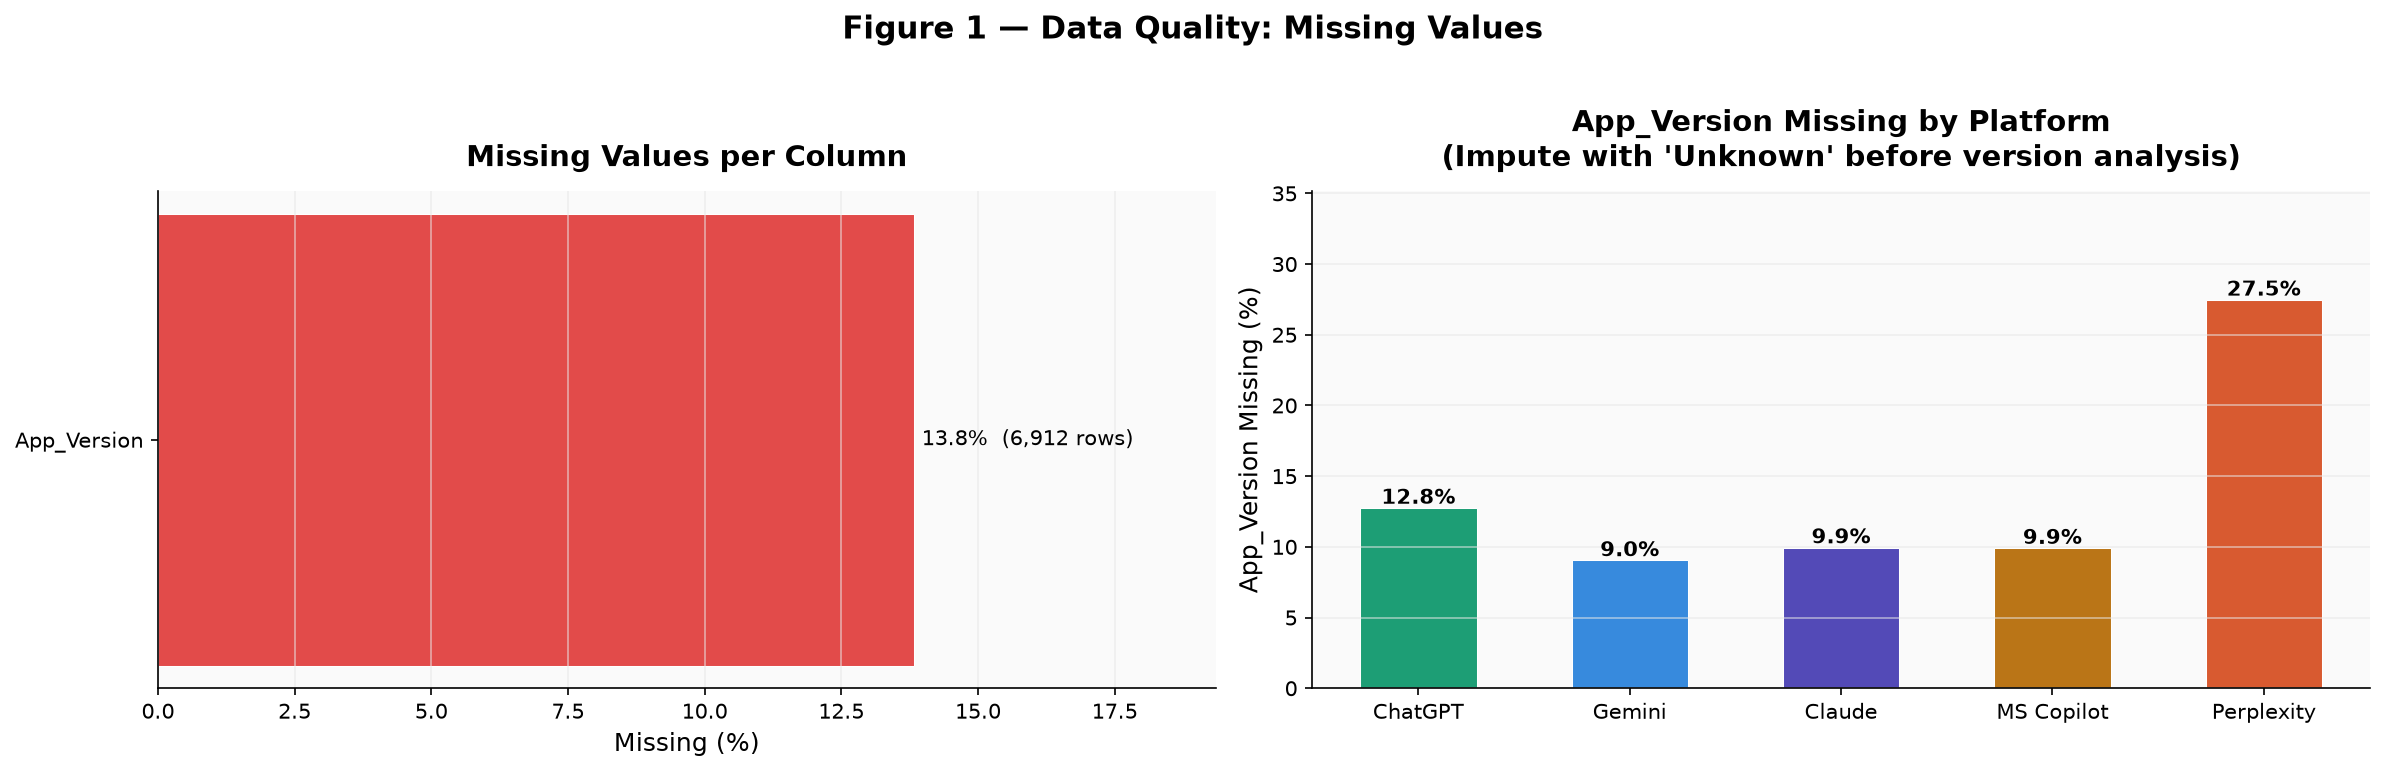

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Left: overall missing values bar ─────────────────────────────────────────
if not missing_df.empty:
    bar_colors = ["#E24B4A" if p > 10 else "#F5923E"
                  for p in missing_df["Missing (%)"]]
    bars = axes[0].barh(
        missing_df["Column"], missing_df["Missing (%)"],
        color=bar_colors, edgecolor="white", linewidth=0.5
    )
    for bar, pct, cnt in zip(bars, missing_df["Missing (%)"], missing_df["Missing"]):
        axes[0].text(
            bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%  ({int(cnt):,} rows)", va="center", fontsize=10
        )
    axes[0].set_xlabel("Missing (%)")
    axes[0].set_xlim(0, missing_df["Missing (%)"].max() * 1.4)
    axes[0].grid(axis="x", alpha=0.6)
else:
    axes[0].text(0.5, 0.5, "No missing values", ha="center", va="center",
                 fontsize=14, transform=axes[0].transAxes, color="#888888")
axes[0].set_title("Missing Values per Column", fontweight="bold", pad=12)

# ── Right: App_Version missing % by platform ──────────────────────────────────
bar_colors_app = [APP_COLORS[a] for a in av_miss["App"]]
bars2 = axes[1].bar(
    av_miss["Label"], av_miss["MissingPct"],
    color=bar_colors_app, edgecolor="white", linewidth=0.5, width=0.55
)
for bar, pct in zip(bars2, av_miss["MissingPct"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
        f"{pct:.1f}%", ha="center", fontsize=10, fontweight="bold"
    )
axes[1].set_ylabel("App_Version Missing (%)")
axes[1].set_ylim(0, av_miss["MissingPct"].max() * 1.28)
axes[1].set_title("App_Version Missing by Platform\n(Impute with 'Unknown' before version analysis)",
                  fontweight="bold", pad=12)
axes[1].grid(axis="y", alpha=0.6)

plt.suptitle("Figure 1 — Data Quality: Missing Values",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_01_missing_values.png")
plt.show()

### 4.2 Duplicate records

**Why:** Exact row duplicates inflate counts and bias models. Duplicate `Review_Text` across platforms may indicate bot activity or coordinated review campaigns — analytically interesting, not just a quality issue.

**Strategy:**
- Exact row duplicates → drop
- Duplicate `Review_Text` → inspect; cross-platform duplicates are flagged as a finding

In [8]:
# ── Exact row duplicates ──────────────────────────────────────────────────────
exact_dups = df.duplicated().sum()
print(f"Exact duplicate rows       : {exact_dups}")

# ── Duplicate Review_Text ─────────────────────────────────────────────────────
dup_text_mask  = df["Review_Text"].duplicated(keep=False)
n_dup_text     = df["Review_Text"].duplicated(keep="first").sum()
print(f"Duplicate Review_Text rows : {dup_text_mask.sum()} rows ({n_dup_text} unique texts duplicated)")

# ── Cross-platform duplicate examples ────────────────────────────────────────
if dup_text_mask.sum() > 0:
    dup_df = df[dup_text_mask].sort_values("Review_Text")
    print("\nSample cross-platform duplicates (first 5):")
    shown = 0
    for text, grp in dup_df.groupby("Review_Text"):
        apps  = grp["App"].tolist()
        stars = grp["Star_Rating"].tolist()
        print(f"  Apps  : {apps}")
        print(f"  Stars : {stars}")
        print(f"  Text  : \"{str(text)[:90]}\"")
        print()
        shown += 1
        if shown >= 5:
            break
else:
    print("  No duplicate Review_Text found.")

Exact duplicate rows       : 0
Duplicate Review_Text rows : 17 rows (9 unique texts duplicated)

Sample cross-platform duplicates (first 5):
  Apps  : ['Microsoft_Copilot', 'Claude']
  Stars : [2, 2]
  Text  : ""The AI system is strong, but the code structure and feature implementation can be further"

  Apps  : ['Google_Gemini', 'Google_Gemini']
  Stars : [3, 5]
  Text  : "Based on this analysis: 1. Suggest at least 10 modern hairstyles that will suit me best. 2"

  Apps  : ['Microsoft_Copilot', 'Google_Gemini']
  Stars : [1, 1]
  Text  : "DO NOT USE THIS. Under any normal circumstances, this app should be labelled as a virus, b"

  Apps  : ['Microsoft_Copilot', 'Perplexity']
  Stars : [1, 1]
  Text  : "Don't use this AI. Always use Google Gemini Ai all information has been correct."

  Apps  : ['Microsoft_Copilot', 'Perplexity', 'Claude']
  Stars : [5, 4, 4]
  Text  : "If you can improve the Kurdish Sorani language, thank you"



### 4.3 Outlier detection

**Why:** Extreme values in `Thumbs_Up_Count` can distort descriptive statistics. The `Word_Count` minimum floor (10 words) suggests possible source truncation. Knowing these boundaries is essential before computing engagement-weighted metrics.

In [9]:
print("── Thumbs_Up_Count ──────────────────────────────────────────────────────────")
tc = df["Thumbs_Up_Count"]
tiers = [(0, 1), (1, 11), (11, 101), (101, 1001), (1001, tc.max() + 1)]
tier_labels = ["0 thumbs", "1 – 10", "11 – 100", "101 – 1,000", "> 1,000"]
for (lo, hi), label in zip(tiers, tier_labels):
    cnt = ((tc >= lo) & (tc < hi)).sum()
    print(f"  {label:<14} : {cnt:>7,}  ({cnt / len(df) * 100:.1f}%)")
print(f"  Maximum        : {tc.max():>7,}")

print()
print("  Top 5 most-endorsed reviews:")
top5 = df.nlargest(5, "Thumbs_Up_Count")[
    ["App", "Star_Rating", "Thumbs_Up_Count", "Review_Text"]
]
for _, row in top5.iterrows():
    print(f"    [{APP_LABELS[row['App']]}] "
          f"Star={row['Star_Rating']}  "
          f"Thumbs={row['Thumbs_Up_Count']:,}")
    print(f"    \"{str(row['Review_Text'])[:100]}\"")
    print()

print("── Word_Count ───────────────────────────────────────────────────────────────")
wc = df["Word_Count"]
min_wc = wc.min()
print(f"  Minimum               : {min_wc}")
print(f"  Reviews at minimum    : {(wc == min_wc).sum():,}  (possible truncation floor)")
print(f"  Maximum               : {wc.max()}")
print(f"  Mean / Median         : {wc.mean():.1f} / {wc.median():.0f}")
print(f"  Reviews with > 100 wds: {(wc > 100).sum():,}")

── Thumbs_Up_Count ──────────────────────────────────────────────────────────
  0 thumbs       :  38,165  (76.3%)
  1 – 10         :  10,870  (21.7%)
  11 – 100       :     836  (1.7%)
  101 – 1,000    :     120  (0.2%)
  > 1,000        :       9  (0.0%)
  Maximum        :   5,447

  Top 5 most-endorsed reviews:
    [Gemini] Star=3  Thumbs=5,447
    "There is way too much lag! it's not exactly seamless if it lags for a solid 30 seconds every time I "

    [Perplexity] Star=1  Thumbs=3,567
    "No voice activation, and the app doesn't preserve any voice settings (like custom speed or accent) b"

    [Gemini] Star=4  Thumbs=2,682
    "As assistant did by quick information and command like "hey Google... set alarm." Yes that's normal "

    [MS Copilot] Star=4  Thumbs=2,672
    "it's a good app for anything that isn't image generation. I get the disclaimer that it might make mi"

    [Perplexity] Star=1  Thumbs=1,690
    ""While using this AI tool in pro, I found that generating precise m

### 4.4 Text integrity check

**Why:** Truncated reviews (ending in "...") provide incomplete sentiment signals. Non-ASCII characters (emoji, Unicode math fonts, non-Latin scripts) require specific normalisation in Notebook 02. Quantifying both informs the pre-processing strategy.

In [10]:
truncated  = df["Review_Text"].str.strip().str.endswith("...").sum()
non_ascii  = df["Review_Text"].apply(
    lambda x: any(ord(c) > 127 for c in str(x))
).sum()
char_mis   = (df["Review_Text"].str.len() != df["Review_Length_Chars"]).sum()
zero_sent  = (df["Sentiment_Polarity"] == 0.0).sum()

print("Text Integrity Summary")
print("=" * 62)
print(f"  Truncated reviews ('...' ending)   : {truncated:>6,}  ({truncated/len(df)*100:.1f}%)")
print(f"  Reviews with non-ASCII characters  : {non_ascii:>6,}  ({non_ascii/len(df)*100:.1f}%)")
print(f"  Review_Length_Chars mismatches     : {char_mis:>6,}  (minor)")
print(f"  Sentiment_Polarity exactly 0.0     : {zero_sent:>6,}  ({zero_sent/len(df)*100:.1f}%)")
print("=" * 62)
print()
print("Implications for Notebook 02:")
print("  → Normalise Unicode (unicodedata + ftfy)")
print("  → Expand contractions (contractions library)")
print("  → Flag truncated reviews for exclusion from deep semantic analysis")
print()
print("Implications for Notebook 03:")
print("  → Recompute ALL sentiment scores — do not rely on Sentiment_Polarity alone")
print("  → 10.1% zero-sentiment reviews may represent neutral OR failed computation")

Text Integrity Summary
  Truncated reviews ('...' ending)   :    622  (1.2%)
  Reviews with non-ASCII characters  :  8,594  (17.2%)
  Review_Length_Chars mismatches     :     10  (minor)
  Sentiment_Polarity exactly 0.0     :  5,051  (10.1%)

Implications for Notebook 02:
  → Normalise Unicode (unicodedata + ftfy)
  → Expand contractions (contractions library)
  → Flag truncated reviews for exclusion from deep semantic analysis

Implications for Notebook 03:
  → Recompute ALL sentiment scores — do not rely on Sentiment_Polarity alone
  → 10.1% zero-sentiment reviews may represent neutral OR failed computation


---
## 📊 Section 5 — Univariate Analysis

We examine the distribution of each column in isolation. These charts form the backbone of the final report's data description section.

### 5.1 Platform distribution

**Why:** Confirming equal representation (10,000 reviews per platform) validates that all subsequent cross-platform comparisons are not biased by sample size.

  📁  Saved → ../outputs/figures/fig_02_app_distribution.png


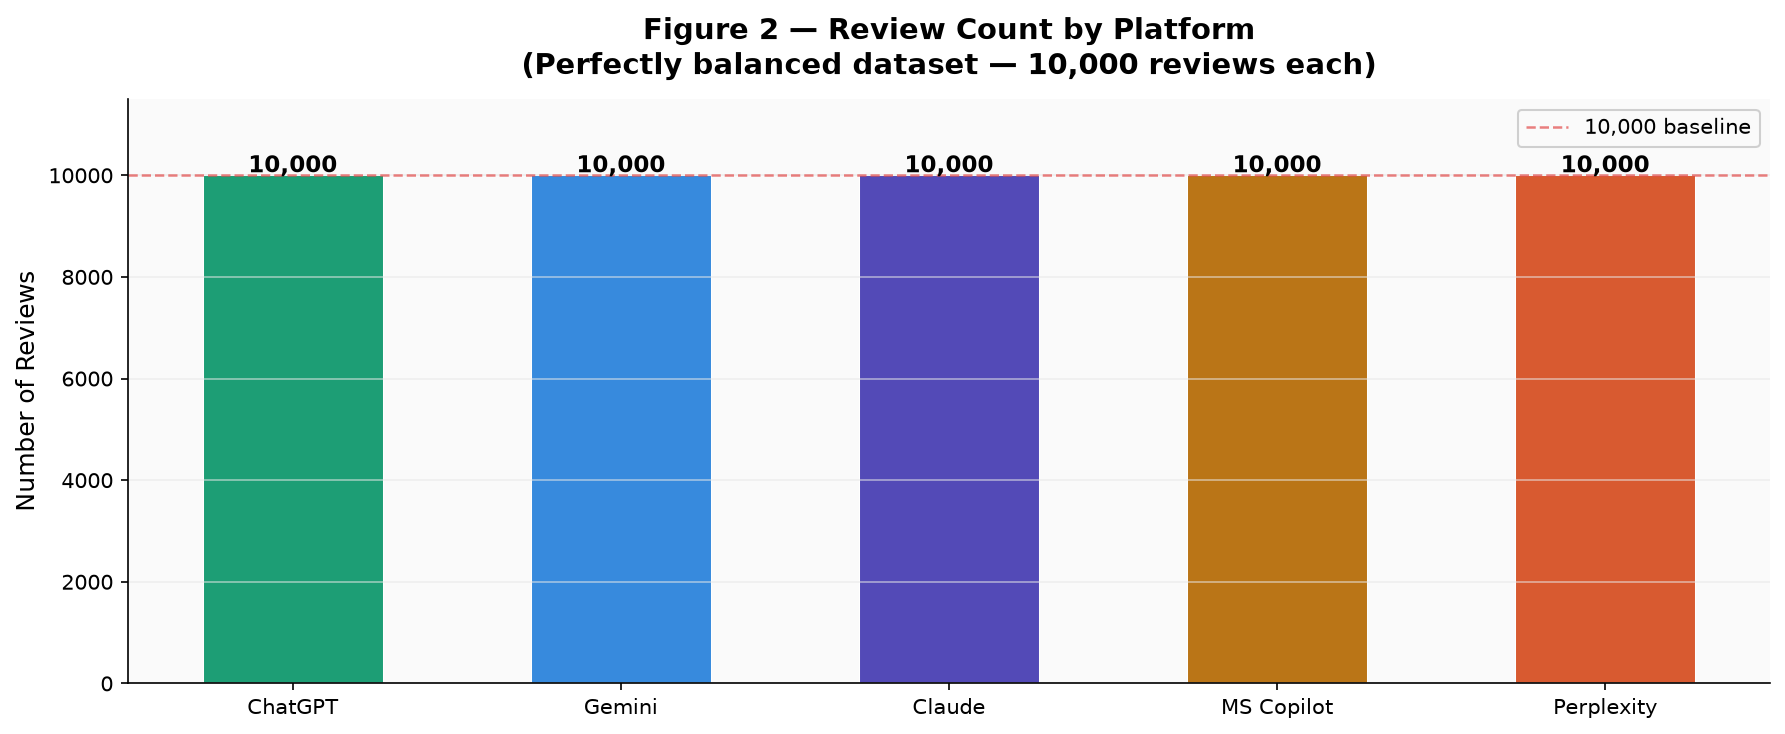

Platform counts:
  ChatGPT        : 10,000
  Gemini         : 10,000
  Claude         : 10,000
  MS Copilot     : 10,000
  Perplexity     : 10,000


In [11]:
app_counts  = df["App"].value_counts().reindex(APP_ORDER)
app_display = [APP_LABELS[a] for a in APP_ORDER]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(app_display, app_counts.values,
              color=PALETTE, edgecolor="white", linewidth=0.5, width=0.55)
for bar, val in zip(bars, app_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 60,
            f"{val:,}", ha="center", fontsize=11, fontweight="bold")

ax.axhline(10_000, color="#E24B4A", linestyle="--", linewidth=1.2,
           alpha=0.7, label="10,000 baseline")
ax.set_ylabel("Number of Reviews")
ax.set_ylim(0, app_counts.max() * 1.15)
ax.set_title(
    "Figure 2 — Review Count by Platform\n"
    "(Perfectly balanced dataset — 10,000 reviews each)",
    fontweight="bold", pad=12
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.6)

plt.tight_layout()
save_fig("fig_02_app_distribution.png")
plt.show()

print("Platform counts:")
for app, cnt in app_counts.items():
    print(f"  {APP_LABELS[app]:<14} : {cnt:,}")

### 5.2 Star rating distribution

**Why:** App store reviews follow a characteristic **J-shaped bimodal distribution** — heavily skewed toward 1-star and 5-star ratings. Understanding this shape is essential because:
1. It signals class imbalance for any rating prediction task
2. It confirms that 3-star "neutral" reviews are underrepresented
3. Cross-platform differences in this shape reveal relative user polarisation

  📁  Saved → ../outputs/figures/fig_03_star_rating_distribution.png


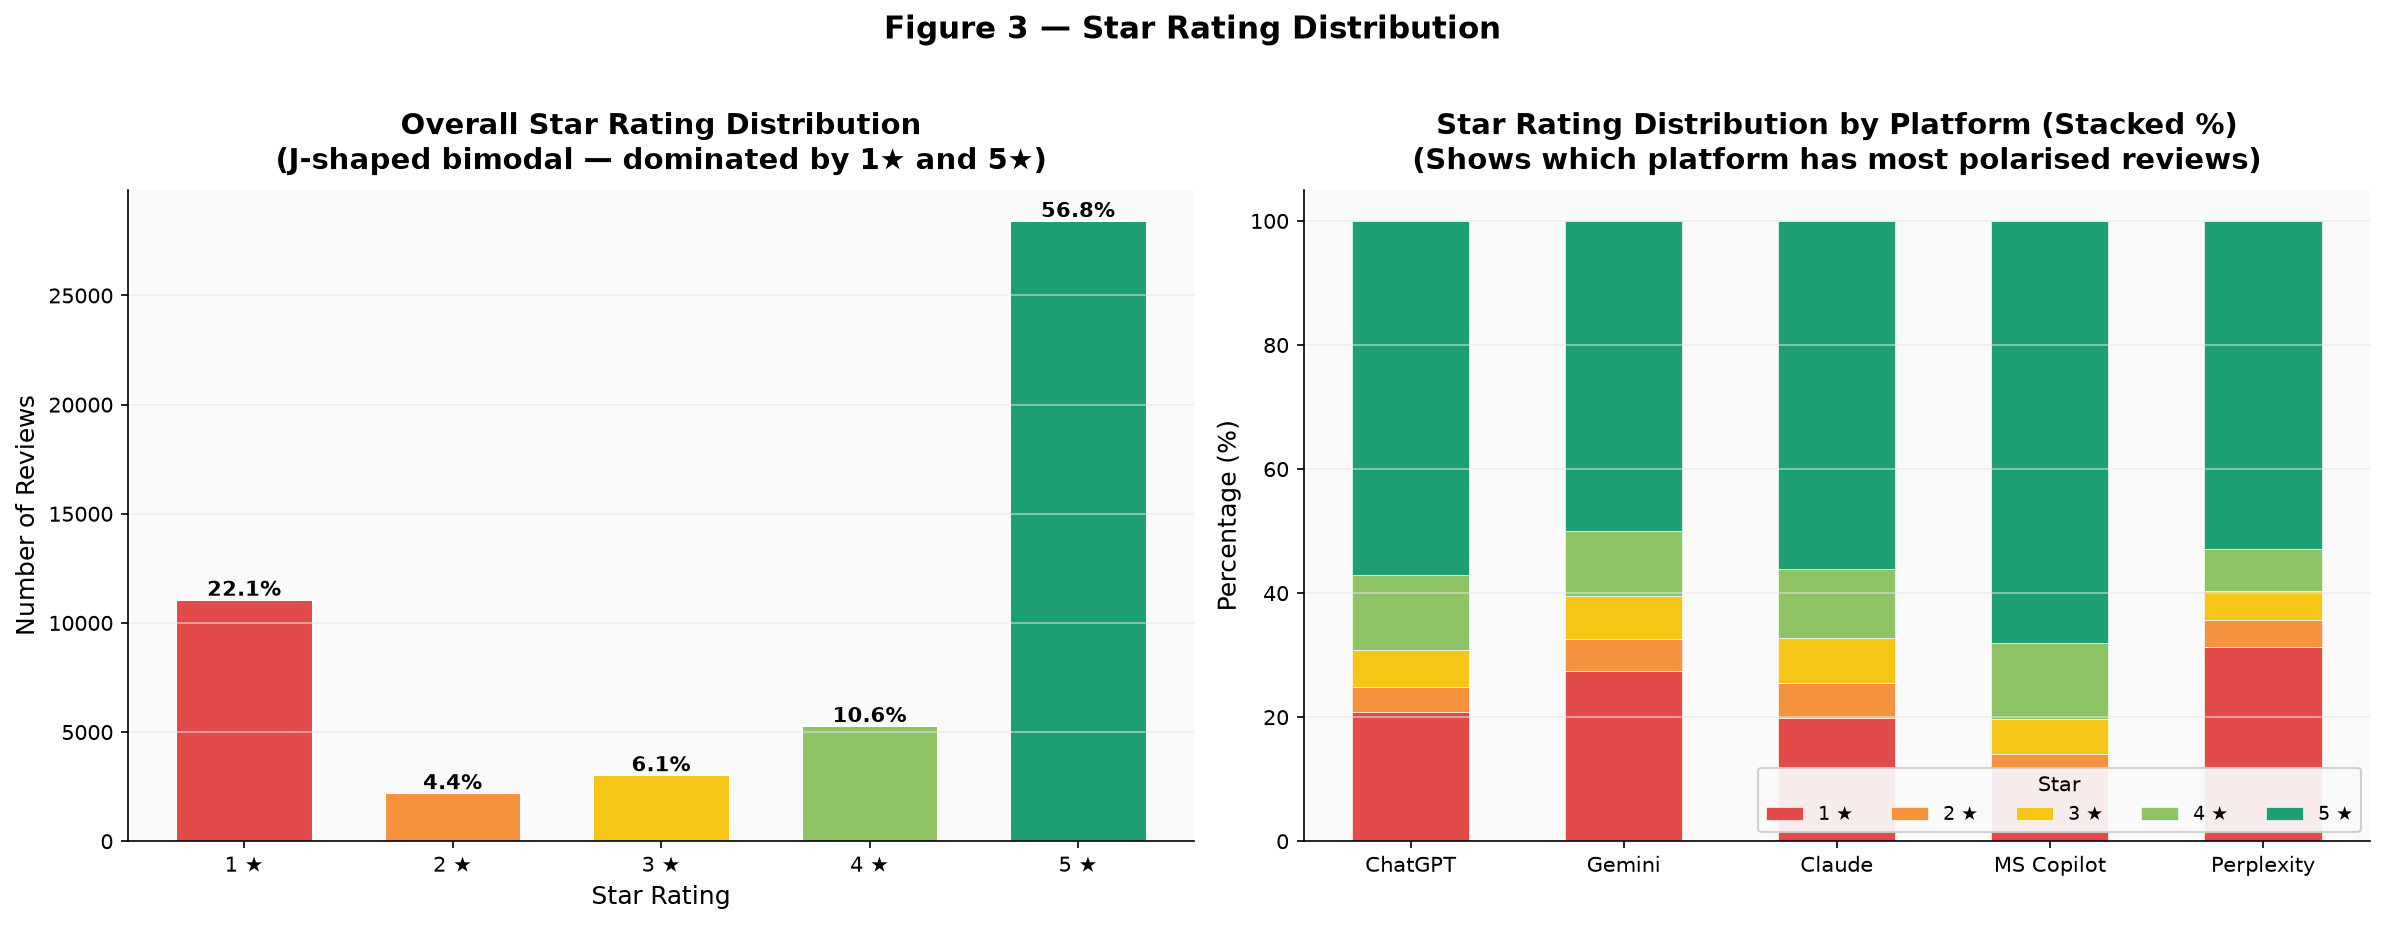


Overall star rating breakdown:
  1 ★ : 11,068  (22.1%)
  2 ★ :  2,207  (4.4%)
  3 ★ :  3,030  (6.1%)
  4 ★ :  5,281  (10.6%)
  5 ★ : 28,414  (56.8%)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: overall star distribution ──────────────────────────────────────────
overall_stars = df["Star_Rating"].value_counts().sort_index()
bars = axes[0].bar(
    [1, 2, 3, 4, 5], overall_stars.values,
    color=STAR_COLORS, edgecolor="white", linewidth=0.5, width=0.65
)
for bar, val in zip(bars, overall_stars.values):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 180,
        f"{pct:.1f}%", ha="center", fontsize=10, fontweight="bold"
    )
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xticklabels(["1 ★", "2 ★", "3 ★", "4 ★", "5 ★"])
axes[0].set_title(
    "Overall Star Rating Distribution\n(J-shaped bimodal — dominated by 1★ and 5★)",
    fontweight="bold", pad=10
)
axes[0].grid(axis="y", alpha=0.6)

# ── Right: stacked % per platform ────────────────────────────────────────────
star_pct = (
    df.groupby(["App", "Star_Rating"])
      .size()
      .reset_index(name="Count")
)
star_pct["Pct"] = (
    star_pct.groupby("App")["Count"]
            .transform(lambda x: x / x.sum() * 100)
)
pivot = (
    star_pct.pivot(index="App", columns="Star_Rating", values="Pct")
            .fillna(0)
            .reindex(APP_ORDER)
)
pivot.index = [APP_LABELS[a] for a in APP_ORDER]

bottom = np.zeros(len(APP_ORDER))
for star, color in zip([1, 2, 3, 4, 5], STAR_COLORS):
    vals = pivot[star].values
    axes[1].bar(
        pivot.index, vals, bottom=bottom,
        color=color, label=f"{star} ★",
        edgecolor="white", linewidth=0.3, width=0.55
    )
    bottom += vals

axes[1].set_ylabel("Percentage (%)")
axes[1].set_title(
    "Star Rating Distribution by Platform (Stacked %)\n"
    "(Shows which platform has most polarised reviews)",
    fontweight="bold", pad=10
)
axes[1].legend(title="Star", loc="lower right", ncol=5, fontsize=9)
axes[1].grid(axis="y", alpha=0.6)

plt.suptitle("Figure 3 — Star Rating Distribution",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_03_star_rating_distribution.png")
plt.show()

print("\nOverall star rating breakdown:")
for s, cnt in overall_stars.items():
    print(f"  {s} ★ : {cnt:>6,}  ({cnt / len(df) * 100:.1f}%)")

### 5.3 Temporal analysis — collection windows & monthly volume

> ⚠️ **Critical finding:** The five platforms have drastically unequal review collection windows. This is the most important structural insight from the EDA and **must be documented in the project methodology**.
>
> - **ChatGPT** and **Gemini** have only ~3 weeks and ~5 weeks of data respectively.
> - **Claude** has 10.5 months of data.
> - **Direct cross-platform time-series comparisons must be restricted to the shared March 2026 overlap window.**

In [13]:
date_ranges = (
    df.groupby("App")["Review_Date"]
      .agg(["min", "max", "count"])
      .reindex(APP_ORDER)
)
date_ranges["days"]  = (date_ranges["max"] - date_ranges["min"]).dt.days
date_ranges["label"] = [APP_LABELS[a] for a in APP_ORDER]

print("=" * 78)
print("  CRITICAL: Temporal collection windows differ significantly")
print("=" * 78)
for app in APP_ORDER:
    row = date_ranges.loc[app]
    print(f"  {APP_LABELS[app]:<14} : {str(row['min'].date())} → {str(row['max'].date())}"
          f"  |  {row['days']:>4} days  |  {row['count']:>6,} reviews")
print("=" * 78)
print()

march_counts = (
    df[df["Review_Date"].dt.month == 3]
      .groupby("App").size()
      .reindex(APP_ORDER)
)
total_march = march_counts.sum()
print(f"Reviews in March 2026 (shared window) : {total_march:,}  ({total_march/len(df)*100:.1f}% of total)")
print()
print("→ Time-series cross-platform analysis will use March 2026 window only.")

  CRITICAL: Temporal collection windows differ significantly
  ChatGPT        : 2026-03-09 → 2026-03-31  |    22 days  |  10,000 reviews
  Gemini         : 2026-02-25 → 2026-03-31  |    33 days  |  10,000 reviews
  Claude         : 2025-05-13 → 2026-03-31  |   322 days  |  10,000 reviews
  MS Copilot     : 2025-08-25 → 2026-03-31  |   218 days  |  10,000 reviews
  Perplexity     : 2025-10-04 → 2026-03-31  |   177 days  |  10,000 reviews

Reviews in March 2026 (shared window) : 25,150  (50.3% of total)

→ Time-series cross-platform analysis will use March 2026 window only.


  📁  Saved → ../outputs/figures/fig_04_05_temporal_analysis.png


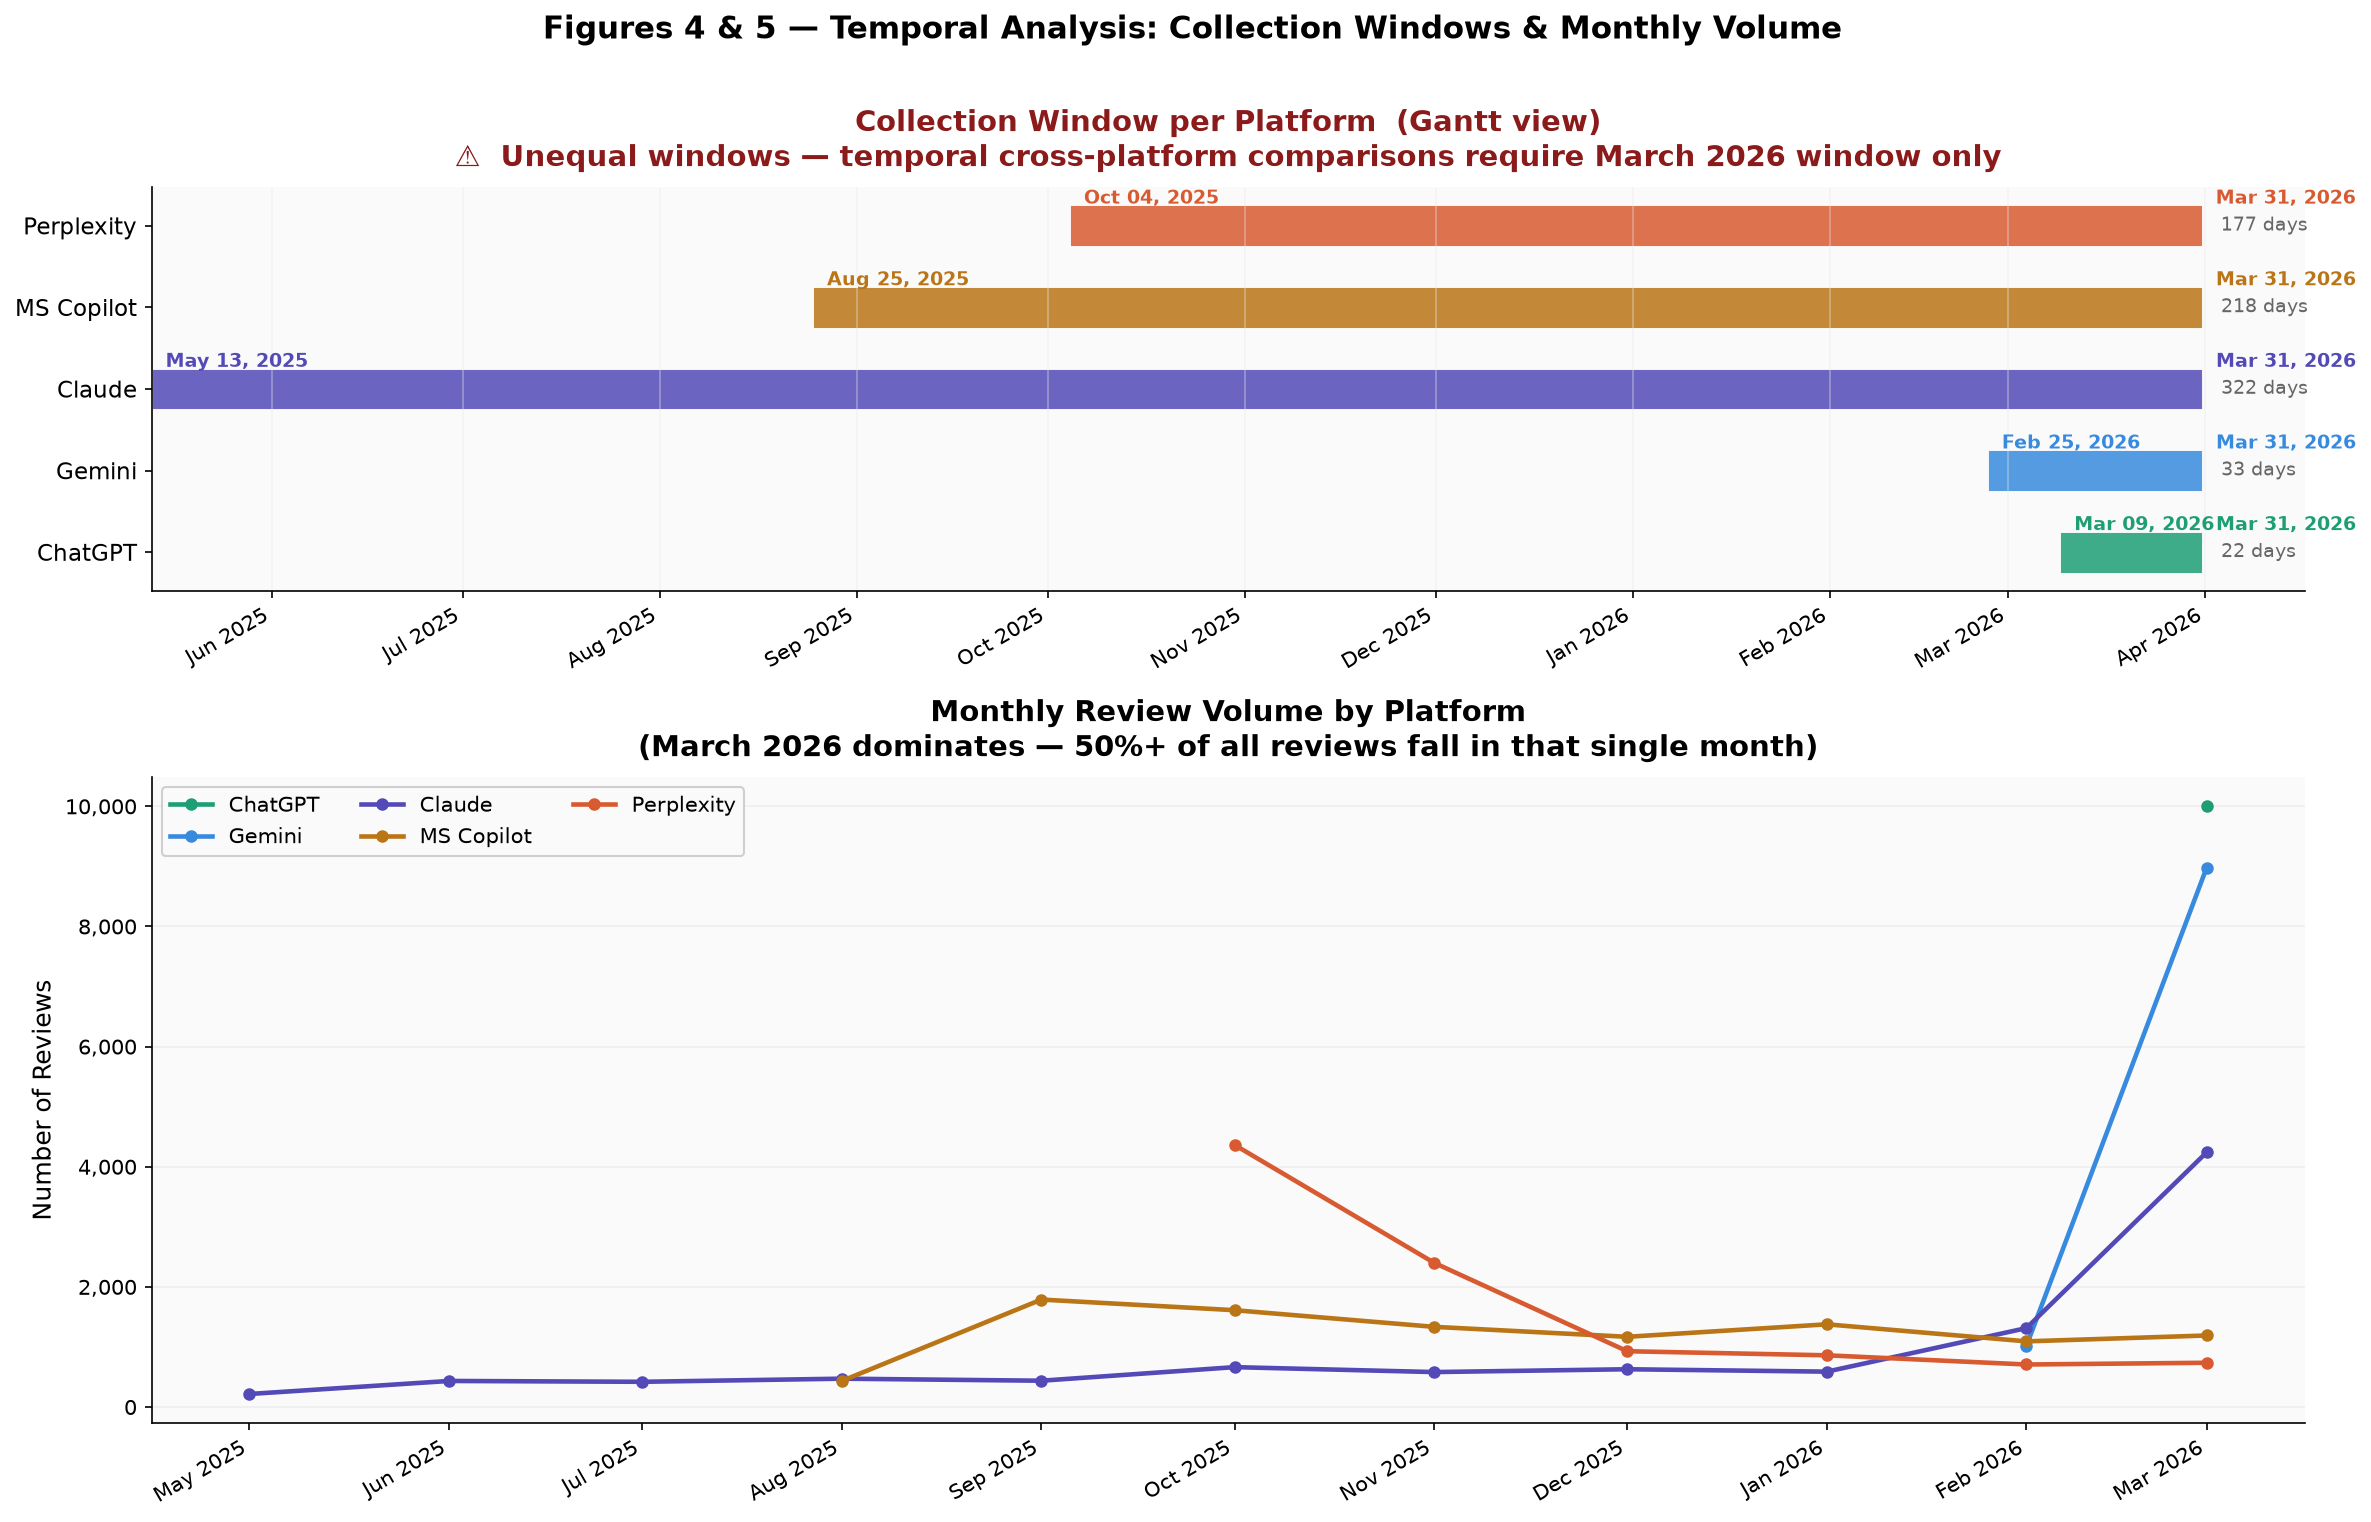

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10),
                         gridspec_kw={"height_ratios": [1, 1.6]})

# ── Top: Gantt-style collection windows ───────────────────────────────────────
for i, app in enumerate(APP_ORDER):
    row   = date_ranges.loc[app]
    start = row["min"]
    end   = row["max"]
    axes[0].barh(i, end - start, left=start,
                 height=0.5, color=APP_COLORS[app], alpha=0.85,
                 edgecolor="white", linewidth=0.5)
    axes[0].text(start, i + 0.33, f"  {start.strftime('%b %d, %Y')}",
                 va="center", fontsize=9, color=APP_COLORS[app], fontweight="bold")
    axes[0].text(end, i + 0.33, f"  {end.strftime('%b %d, %Y')}",
                 va="center", fontsize=9, color=APP_COLORS[app], fontweight="bold")
    axes[0].text(end + pd.Timedelta(days=3), i,
                 f"{int(row['days'])} days", va="center",
                 fontsize=9, color="#666666")

axes[0].set_yticks(range(len(APP_ORDER)))
axes[0].set_yticklabels([APP_LABELS[a] for a in APP_ORDER], fontsize=11)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha="right")
axes[0].set_title(
    "Collection Window per Platform  (Gantt view)\n"
    "⚠  Unequal windows — temporal cross-platform comparisons require March 2026 window only",
    fontweight="bold", color="#8B1A1A", pad=10
)
axes[0].grid(axis="x", alpha=0.4)

# ── Bottom: Monthly review volume line chart ───────────────────────────────────
monthly = (
    df.assign(YM=df["Review_Date"].dt.to_period("M"))
      .groupby(["YM", "App"])
      .size()
      .reset_index(name="Count")
)
monthly["Date"] = monthly["YM"].dt.to_timestamp()

for app in APP_ORDER:
    sub = monthly[monthly["App"] == app].sort_values("Date")
    axes[1].plot(sub["Date"], sub["Count"],
                 marker="o", markersize=5, linewidth=2.2,
                 label=APP_LABELS[app], color=APP_COLORS[app])

axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha="right")
axes[1].set_ylabel("Number of Reviews")
axes[1].set_title(
    "Monthly Review Volume by Platform\n"
    "(March 2026 dominates — 50%+ of all reviews fall in that single month)",
    fontweight="bold", pad=10
)
axes[1].legend(loc="upper left", ncol=3)
axes[1].grid(axis="y", alpha=0.6)
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

plt.suptitle("Figures 4 & 5 — Temporal Analysis: Collection Windows & Monthly Volume",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
save_fig("fig_04_05_temporal_analysis.png")
plt.show()

### 5.4 Review length distribution

**Why:** Review length affects NLP quality directly. Very short reviews may be too sparse for topic modelling. The word count floor at 10 words suggests possible source truncation at the data collection stage.

  📁  Saved → ../outputs/figures/fig_06_review_length_distribution.png


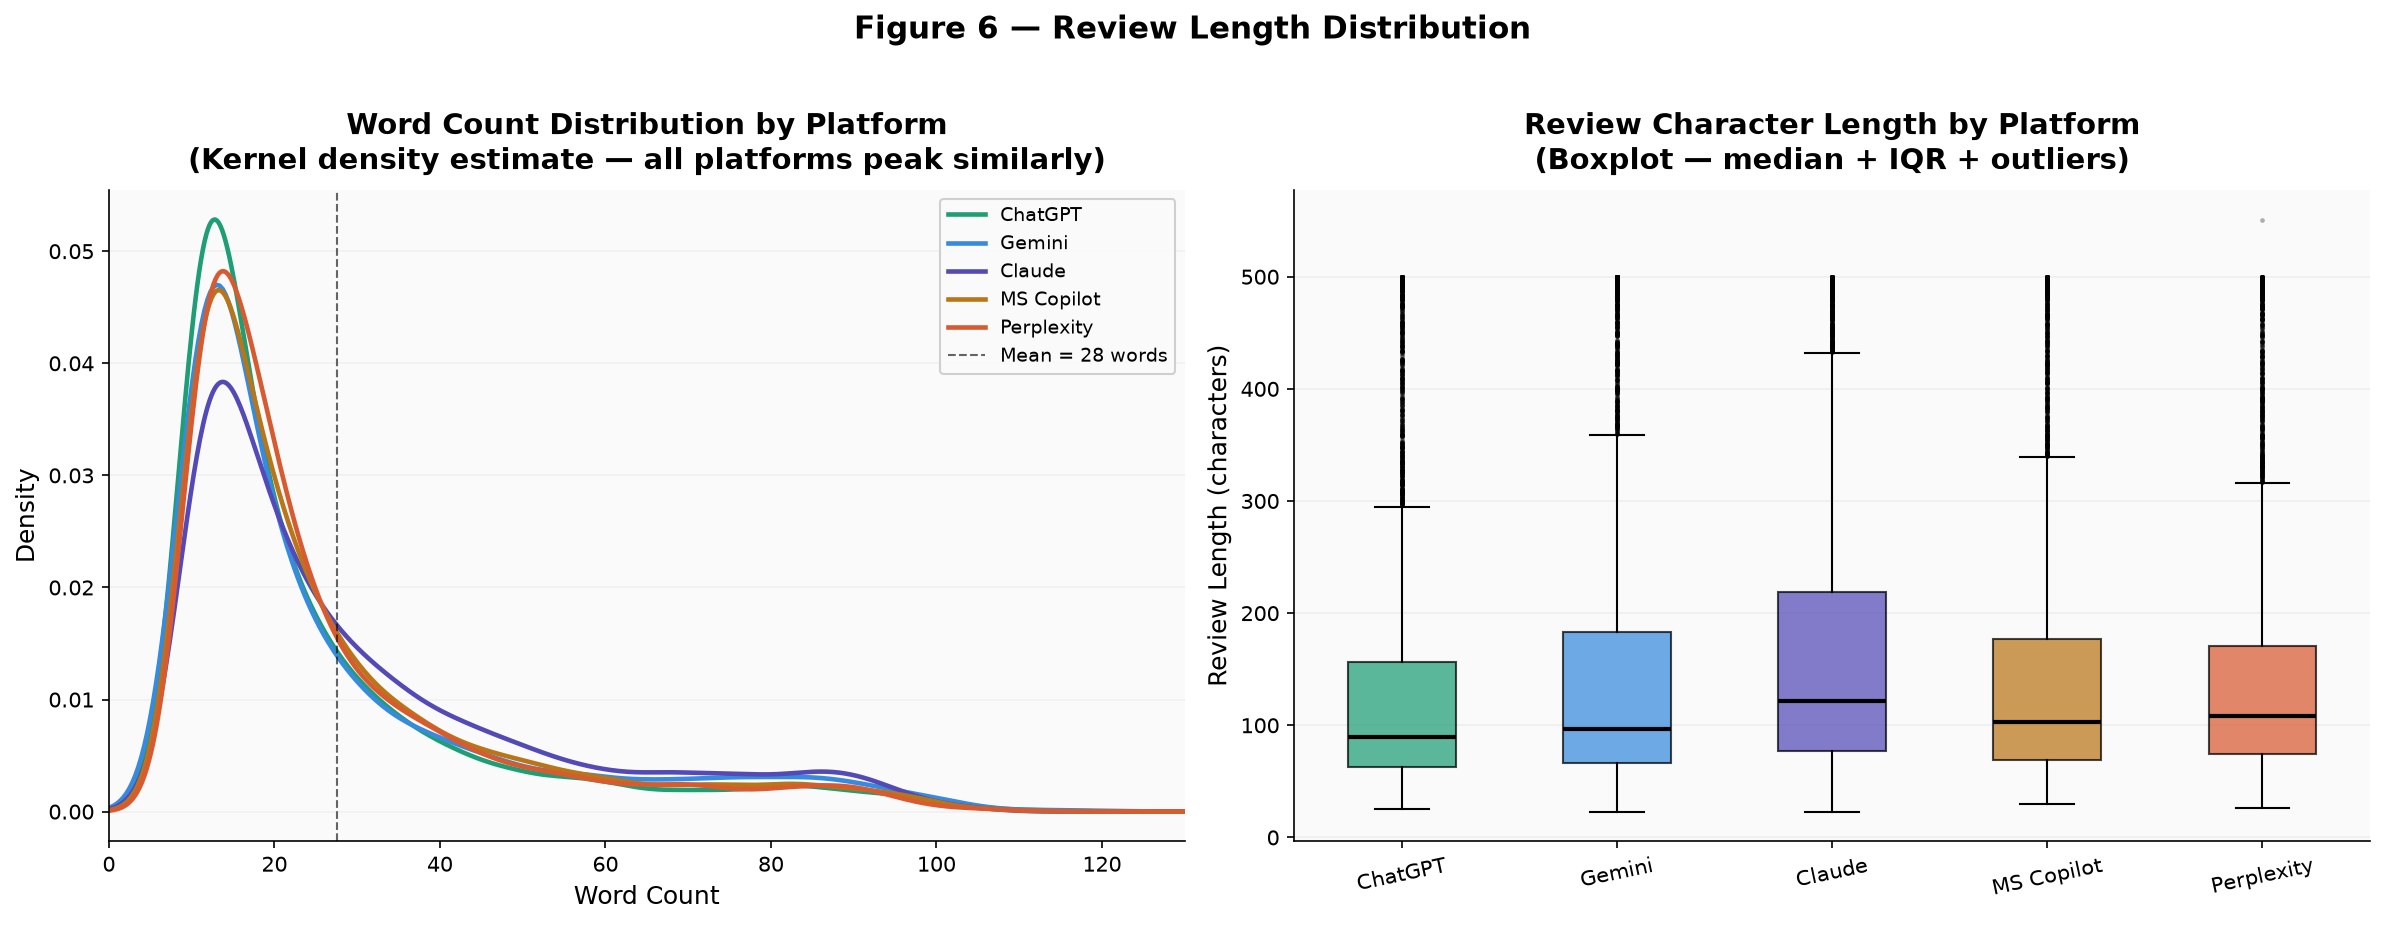

Word count statistics by platform:
              mean  median  min  max
App                                 
ChatGPT    25.5000 17.0000   10  117
Claude     30.7000 22.0000   10  107
Gemini     27.9000 18.0000   10  192
MS Copilot 27.1000 19.0000   10  116
Perplexity 26.4000 19.0000   10  128


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: Word count KDE per platform ────────────────────────────────────────
for app in APP_ORDER:
    df[df["App"] == app]["Word_Count"].plot(
        kind="kde", ax=axes[0], linewidth=2.2,
        color=APP_COLORS[app], label=APP_LABELS[app]
    )
overall_mean_wc = df["Word_Count"].mean()
axes[0].axvline(
    overall_mean_wc, color="black", linestyle="--",
    linewidth=1, alpha=0.6,
    label=f"Mean = {overall_mean_wc:.0f} words"
)
axes[0].set_xlabel("Word Count")
axes[0].set_ylabel("Density")
axes[0].set_xlim(0, 130)
axes[0].set_title(
    "Word Count Distribution by Platform\n(Kernel density estimate — all platforms peak similarly)",
    fontweight="bold", pad=10
)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.5)

# ── Right: Character length boxplot per platform ──────────────────────────────
box_data = [df[df["App"] == app]["Review_Length_Chars"].values
            for app in APP_ORDER]
bp = axes[1].boxplot(
    box_data, patch_artist=True, notch=False,
    medianprops={"color": "black", "linewidth": 2},
    flierprops={"marker": ".", "markersize": 2.5, "alpha": 0.3}
)
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.72)

axes[1].set_xticks(range(1, len(APP_ORDER) + 1))
axes[1].set_xticklabels([APP_LABELS[a] for a in APP_ORDER], rotation=12)
axes[1].set_ylabel("Review Length (characters)")
axes[1].set_title(
    "Review Character Length by Platform\n(Boxplot — median + IQR + outliers)",
    fontweight="bold", pad=10
)
axes[1].grid(axis="y", alpha=0.6)

plt.suptitle("Figure 6 — Review Length Distribution",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_06_review_length_distribution.png")
plt.show()

length_stats = (
    df.groupby("App")["Word_Count"]
      .agg(["mean", "median", "min", "max"])
      .round(1)
      .rename(index=APP_LABELS)
)
print("Word count statistics by platform:")
print(length_stats.to_string())

### 5.5 Thumbs-up count distribution

**Why:** The `Thumbs_Up_Count` column is the basis for our **Thumbs-Weighted Sentiment Index (TWSI)** — a novel contribution of this project. The extreme right-skew (76% zero thumbs) directly justifies why we apply a `log(1+x)` transformation when computing TWSI in Notebook 03.

  📁  Saved → ../outputs/figures/fig_07_thumbs_up_distribution.png


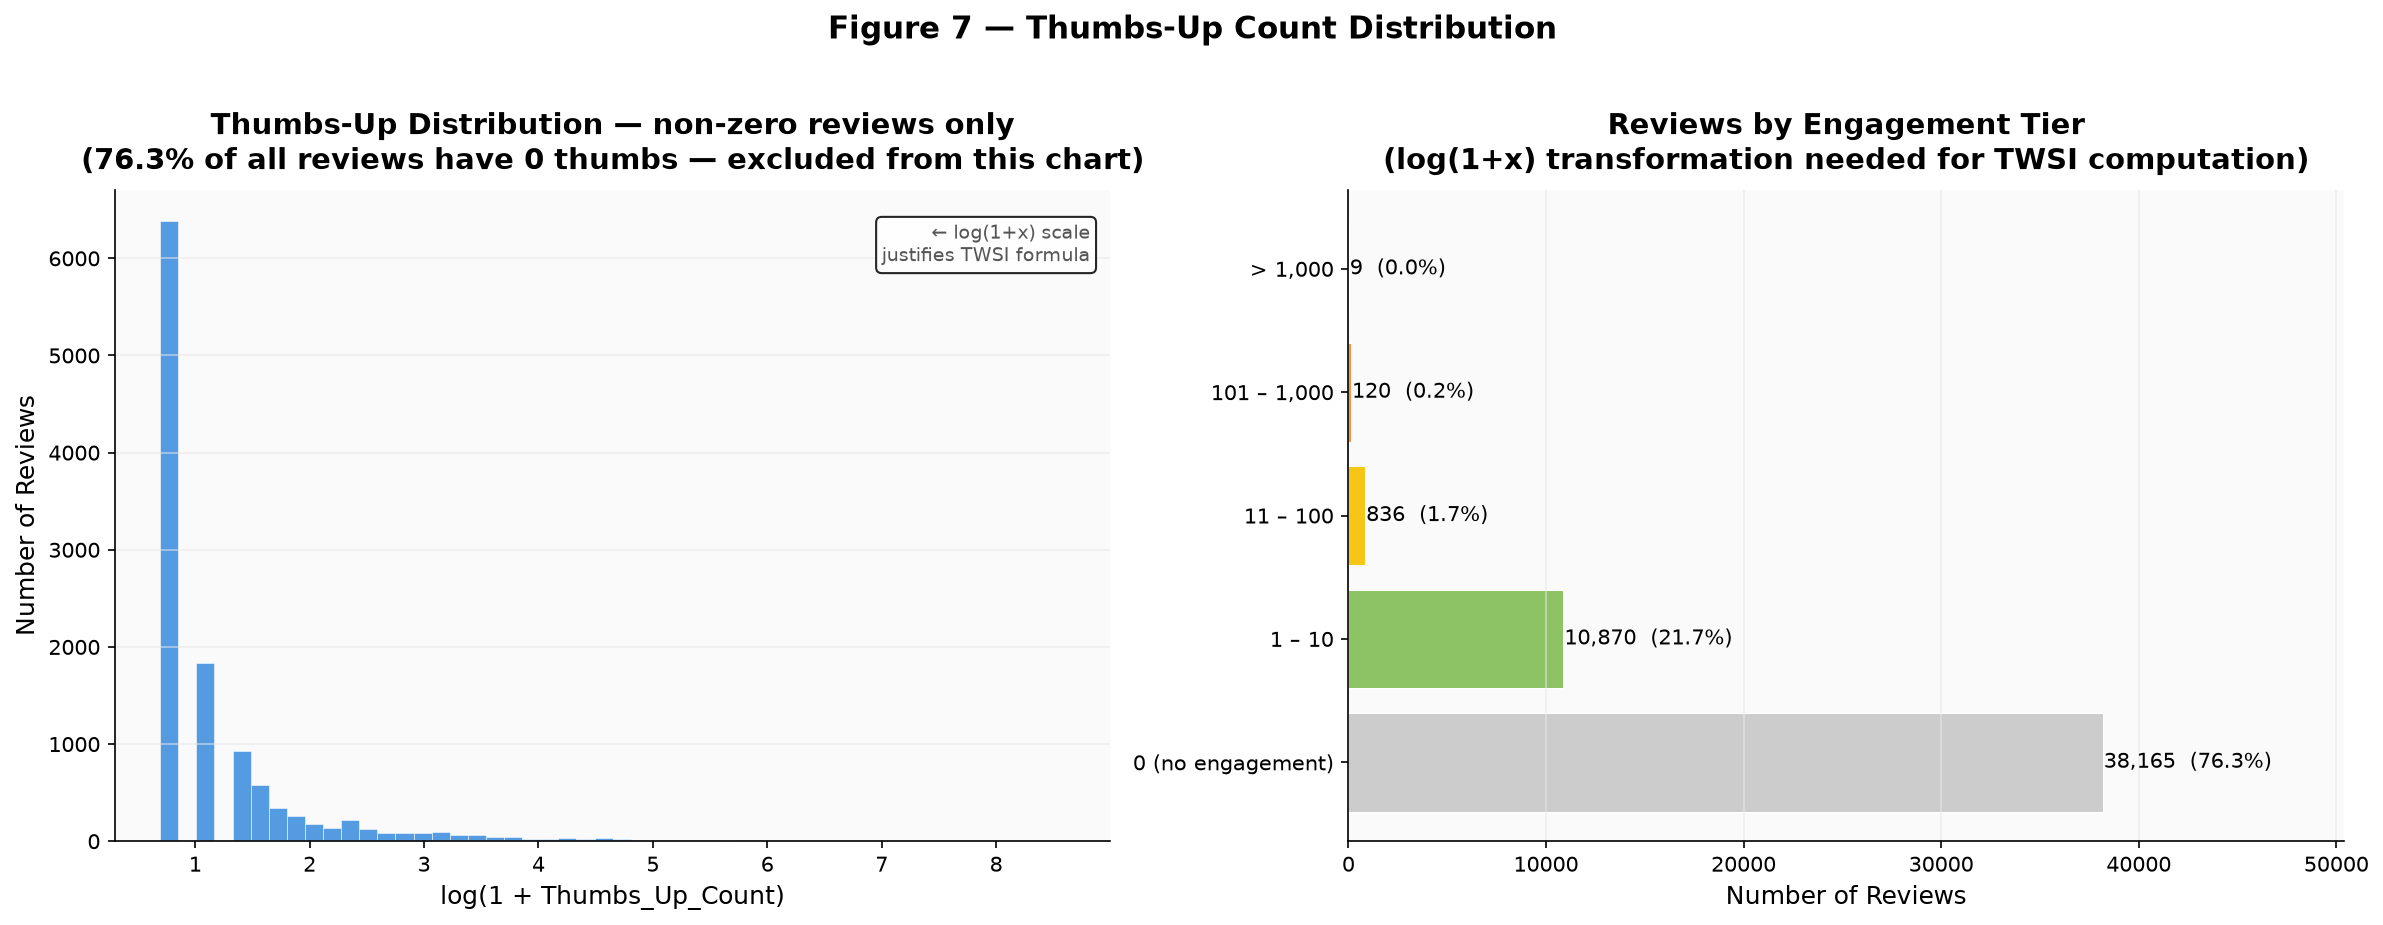

Reviews with 0 thumbs    : 38,165  (76.3%)
Maximum thumbs           : 5,447
Reviews with > 100 thumbs: 129
Reviews with > 1000 thumbs: 9


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: log-scale distribution (non-zero only) ──────────────────────────────
nz = df[df["Thumbs_Up_Count"] > 0]["Thumbs_Up_Count"]
log_vals = np.log1p(nz)
axes[0].hist(log_vals, bins=50, color="#378ADD",
             edgecolor="white", linewidth=0.3, alpha=0.85)
zero_pct = (df["Thumbs_Up_Count"] == 0).mean() * 100
axes[0].set_xlabel("log(1 + Thumbs_Up_Count)")
axes[0].set_ylabel("Number of Reviews")
axes[0].set_title(
    f"Thumbs-Up Distribution — non-zero reviews only\n"
    f"({zero_pct:.1f}% of all reviews have 0 thumbs — excluded from this chart)",
    fontweight="bold", pad=10
)
axes[0].grid(axis="y", alpha=0.6)
axes[0].text(0.98, 0.95, "← log(1+x) scale\njustifies TWSI formula",
             transform=axes[0].transAxes, ha="right", va="top",
             fontsize=9, color="#555555",
             bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

# ── Right: engagement tier horizontal bar ─────────────────────────────────────
edges  = [0, 1, 11, 101, 1001, int(df["Thumbs_Up_Count"].max()) + 1]
labels = ["0 (no engagement)", "1 – 10", "11 – 100", "101 – 1,000", "> 1,000"]
tier_colors = ["#CCCCCC", "#8DC265", "#F5C518", "#F5923E", "#E24B4A"]
counts = [
    ((df["Thumbs_Up_Count"] >= lo) & (df["Thumbs_Up_Count"] < hi)).sum()
    for lo, hi in zip(edges[:-1], edges[1:])
]
bars = axes[1].barh(labels, counts, color=tier_colors,
                    edgecolor="white", linewidth=0.5)
for bar, val in zip(bars, counts):
    pct = val / len(df) * 100
    axes[1].text(
        bar.get_width() + 60,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}  ({pct:.1f}%)", va="center", fontsize=10
    )
axes[1].set_xlabel("Number of Reviews")
axes[1].set_xlim(0, max(counts) * 1.32)
axes[1].set_title(
    "Reviews by Engagement Tier\n(log(1+x) transformation needed for TWSI computation)",
    fontweight="bold", pad=10
)
axes[1].grid(axis="x", alpha=0.6)

plt.suptitle("Figure 7 — Thumbs-Up Count Distribution",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_07_thumbs_up_distribution.png")
plt.show()

print(f"Reviews with 0 thumbs    : {(df['Thumbs_Up_Count']==0).sum():,}  ({(df['Thumbs_Up_Count']==0).mean()*100:.1f}%)")
print(f"Maximum thumbs           : {df['Thumbs_Up_Count'].max():,}")
print(f"Reviews with > 100 thumbs: {(df['Thumbs_Up_Count']>100).sum():,}")
print(f"Reviews with > 1000 thumbs: {(df['Thumbs_Up_Count']>1000).sum():,}")

### 5.6 App_Version analysis

**Why:** `App_Version` allows us to link satisfaction changes to specific product releases. We need to understand the version landscape per platform before planning the version-level analysis.

In [17]:
print("App_Version analysis by platform:")
print("-" * 65)
for app in APP_ORDER:
    sub      = df[df["App"] == app]
    present  = sub["App_Version"].notna().sum()
    total    = len(sub)
    unique   = sub["App_Version"].nunique()
    samples  = sub["App_Version"].dropna().unique()[:3]
    print(f"  {APP_LABELS[app]:<14} : "
          f"{present:>5,}/{total:,} present ({present/total*100:.1f}%)  |  "
          f"{unique:>3} unique versions")
    print(f"               Sample: {list(samples)}")
    print()
print("-" * 65)
print("Strategy: impute missing with 'Unknown' in Notebook 02.")

App_Version analysis by platform:
-----------------------------------------------------------------
  ChatGPT        : 8,725/10,000 present (87.2%)  |   78 unique versions
               Sample: ['1.2026.076', '1.2026.083', '1.2026.055']

  Gemini         : 9,096/10,000 present (91.0%)  |   13 unique versions
               Sample: ['1.0.882555348', '1.0.869192867', '1.0.795460806']

  Claude         : 9,005/10,000 present (90.0%)  |   79 unique versions
               Sample: ['1.260323.7', '1.260309.17', '1.251013.27']

  MS Copilot     : 9,009/10,000 present (90.1%)  |   81 unique versions
               Sample: ['30.0.440325002', '30.0.440220002', '30.0.440309001']

  Perplexity     : 7,253/10,000 present (72.5%)  |   69 unique versions
               Sample: ['2.80.0', '2.78.2', '2.79.3']

-----------------------------------------------------------------
Strategy: impute missing with 'Unknown' in Notebook 02.


### 5.7 Sentiment polarity distribution

**Why:** The pre-labeled `Sentiment_Polarity` column serves as a **baseline** we must validate against our own NLP models in Notebook 03. The 10.1% of reviews with exactly `0.0` polarity are suspicious — truly neutral reviews are rare; these likely indicate failed pre-computation.

  📁  Saved → ../outputs/figures/fig_08_sentiment_polarity.png


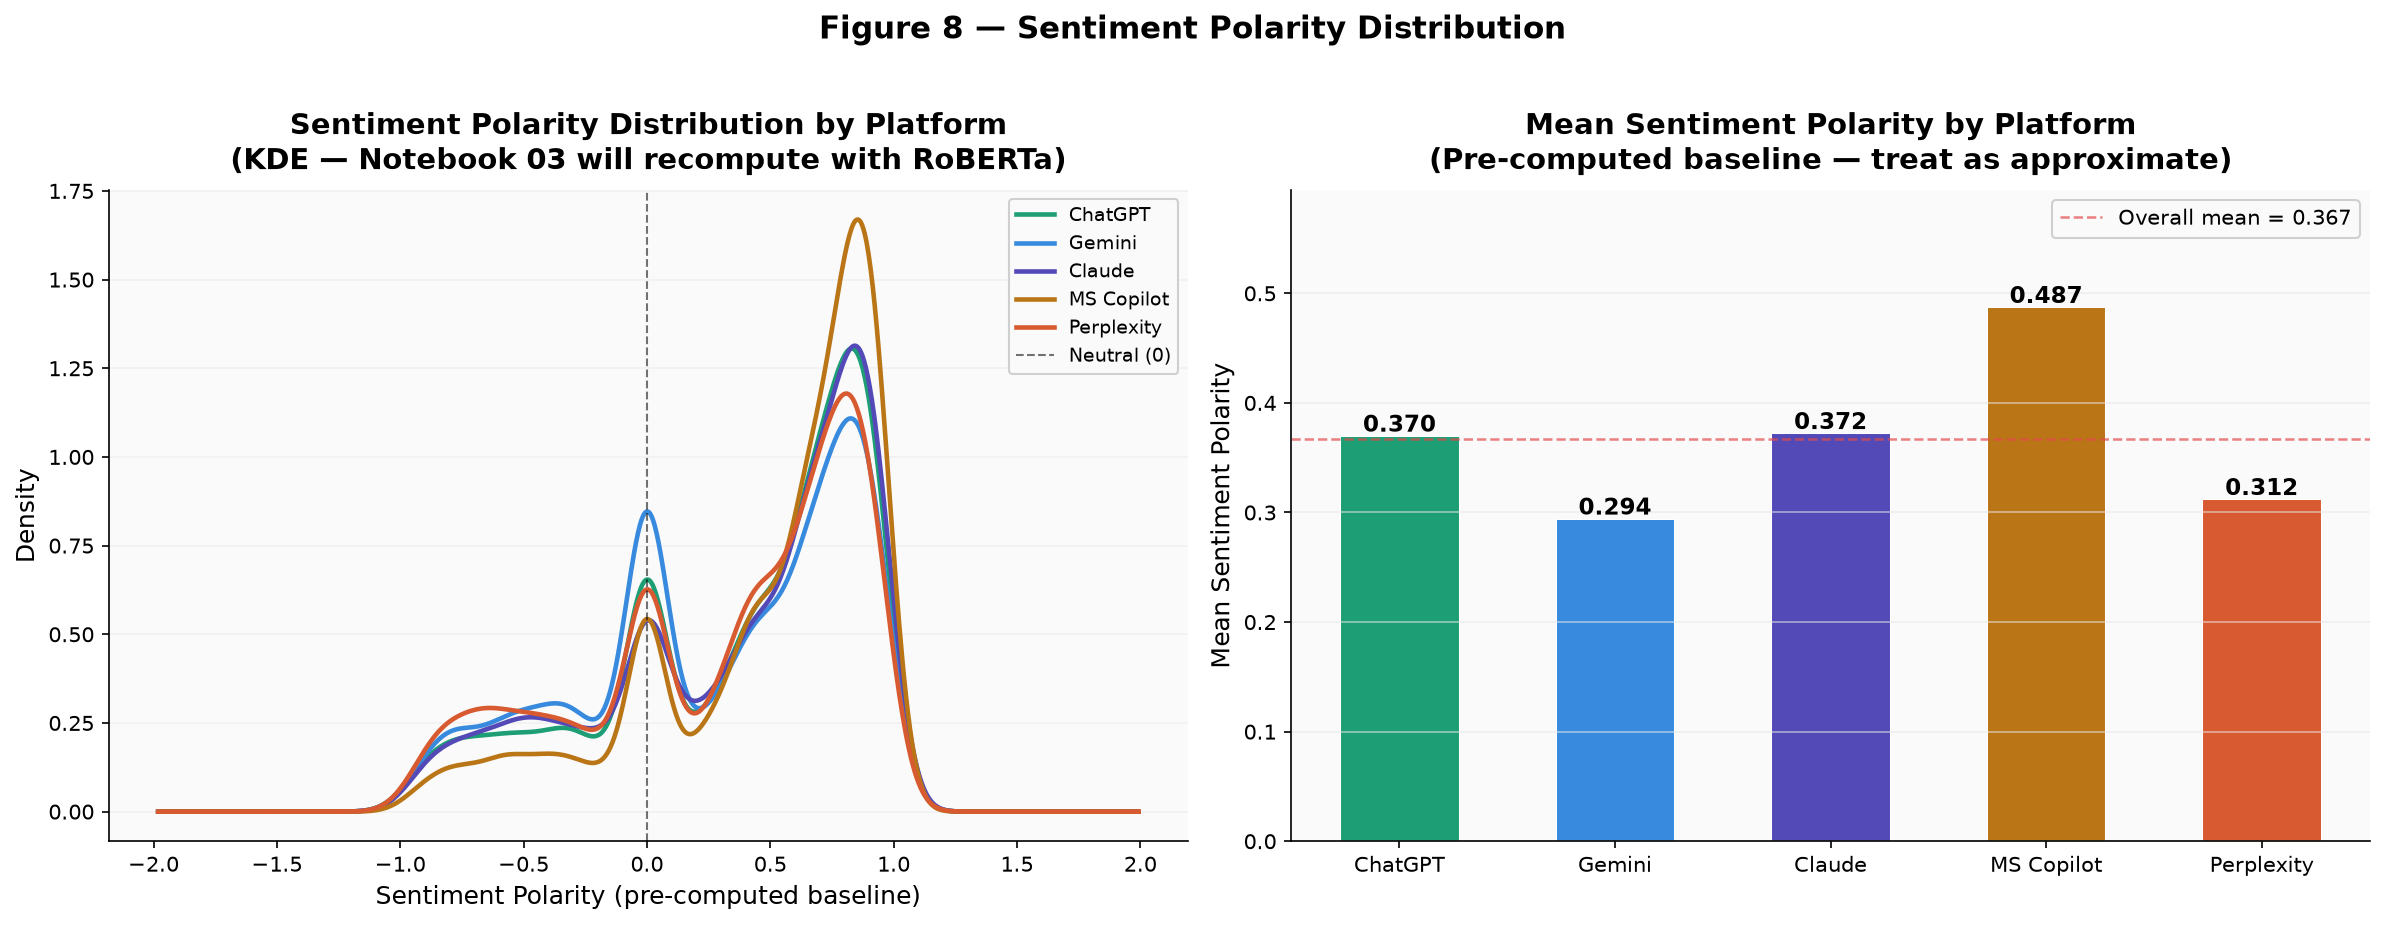

Mean sentiment polarity by platform (baseline):
  ChatGPT        : 0.3697
  Gemini         : 0.2941
  Claude         : 0.3721
  MS Copilot     : 0.4872
  Perplexity     : 0.3119

Reviews with Sentiment_Polarity == 0.0 : 5,051 (10.1%)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: KDE per platform ────────────────────────────────────────────────────
for app in APP_ORDER:
    df[df["App"] == app]["Sentiment_Polarity"].plot(
        kind="kde", ax=axes[0], linewidth=2.2,
        color=APP_COLORS[app], label=APP_LABELS[app]
    )
axes[0].axvline(0, color="black", linestyle="--", linewidth=1,
                alpha=0.55, label="Neutral (0)")
axes[0].set_xlabel("Sentiment Polarity (pre-computed baseline)")
axes[0].set_ylabel("Density")
axes[0].set_title(
    "Sentiment Polarity Distribution by Platform\n(KDE — Notebook 03 will recompute with RoBERTa)",
    fontweight="bold", pad=10
)
axes[0].legend(fontsize=9)
axes[0].grid(axis="y", alpha=0.5)

# ── Right: Mean sentiment per platform ───────────────────────────────────────
mean_sent = df.groupby("App")["Sentiment_Polarity"].mean().reindex(APP_ORDER)
overall_mean = df["Sentiment_Polarity"].mean()
bars = axes[1].bar(
    [APP_LABELS[a] for a in APP_ORDER], mean_sent.values,
    color=PALETTE, edgecolor="white", linewidth=0.5, width=0.55
)
for bar, val in zip(bars, mean_sent.values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
        f"{val:.3f}", ha="center", fontsize=11, fontweight="bold"
    )
axes[1].axhline(overall_mean, color="#E24B4A", linestyle="--",
                linewidth=1.2, alpha=0.7,
                label=f"Overall mean = {overall_mean:.3f}")
axes[1].set_ylabel("Mean Sentiment Polarity")
axes[1].set_ylim(0, mean_sent.max() * 1.22)
axes[1].set_title(
    "Mean Sentiment Polarity by Platform\n(Pre-computed baseline — treat as approximate)",
    fontweight="bold", pad=10
)
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.6)

plt.suptitle("Figure 8 — Sentiment Polarity Distribution",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_08_sentiment_polarity.png")
plt.show()

zero_sent = (df["Sentiment_Polarity"] == 0.0).sum()
print("Mean sentiment polarity by platform (baseline):")
for app in APP_ORDER:
    print(f"  {APP_LABELS[app]:<14} : {mean_sent[app]:.4f}")
print(f"\nReviews with Sentiment_Polarity == 0.0 : {zero_sent:,} ({zero_sent/len(df)*100:.1f}%)")

### 5.8 Review theme distribution

**Why:** The pre-labeled `Review_Theme` column categorises reviews into 4 themes. However, with **85.9% classified as "General"**, it is far too coarse for meaningful topic discovery. This is the primary justification for running LDA and BERTopic topic modelling in Notebook 04.

  📁  Saved → ../outputs/figures/fig_09_review_theme_distribution.png


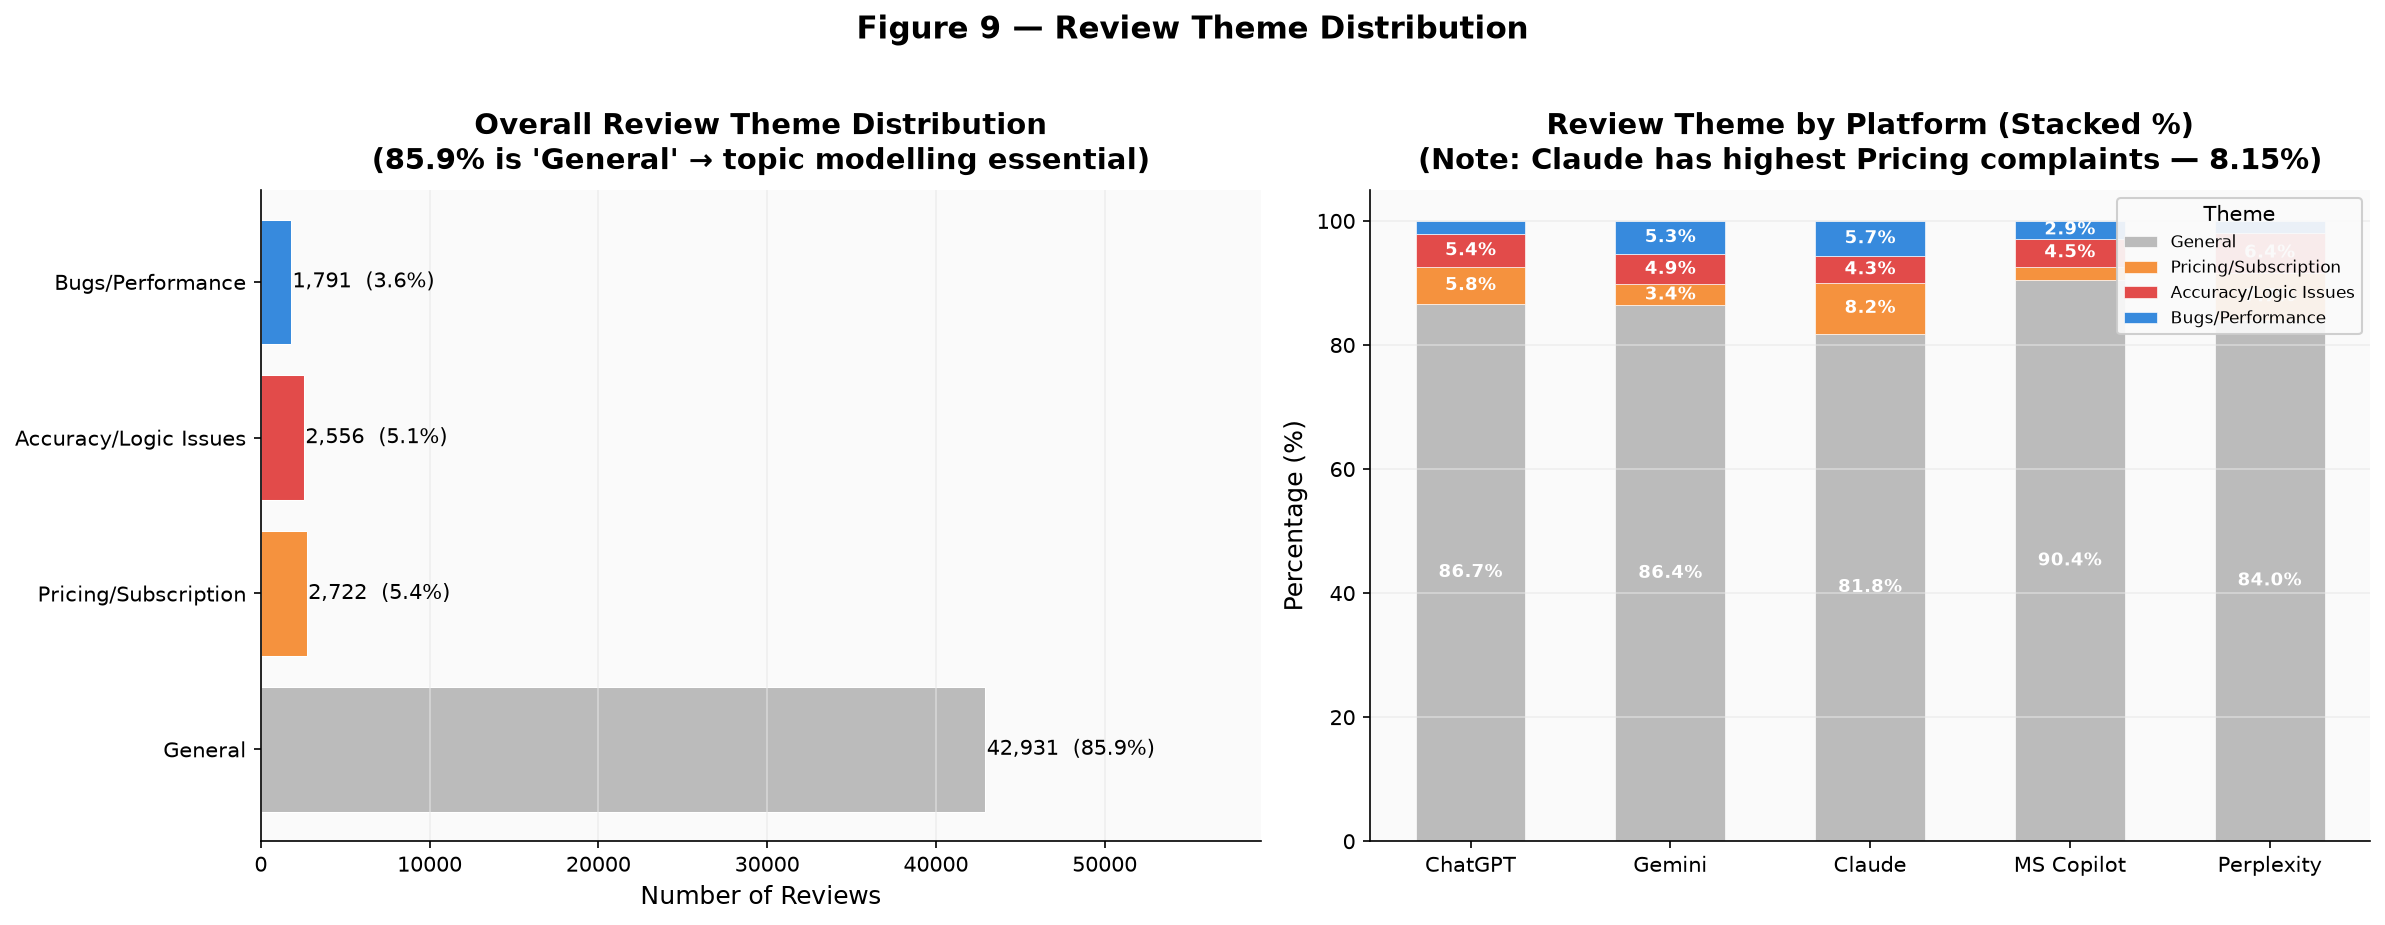


Review theme counts:
Review_Theme
General                  42931
Pricing/Subscription      2722
Accuracy/Logic Issues     2556
Bugs/Performance          1791


In [19]:
theme_counts = df["Review_Theme"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
theme_palette = ["#BBBBBB", "#F5923E", "#E24B4A", "#378ADD"]
themes_ordered = theme_counts.index.tolist()

# ── Left: overall theme horizontal bar ───────────────────────────────────────
bars = axes[0].barh(
    themes_ordered, theme_counts.values,
    color=theme_palette[:len(themes_ordered)],
    edgecolor="white", linewidth=0.5
)
for bar, val in zip(bars, theme_counts.values):
    pct = val / len(df) * 100
    axes[0].text(
        bar.get_width() + 80,
        bar.get_y() + bar.get_height() / 2,
        f"{val:,}  ({pct:.1f}%)", va="center", fontsize=10
    )
axes[0].set_xlabel("Number of Reviews")
axes[0].set_xlim(0, theme_counts.max() * 1.38)
axes[0].set_title(
    "Overall Review Theme Distribution\n(85.9% is 'General' → topic modelling essential)",
    fontweight="bold", pad=10
)
axes[0].grid(axis="x", alpha=0.6)

# ── Right: stacked % by platform ─────────────────────────────────────────────
theme_by_app = (
    df.groupby(["App", "Review_Theme"])
      .size()
      .reset_index(name="Count")
)
theme_by_app["Pct"] = (
    theme_by_app.groupby("App")["Count"]
                .transform(lambda x: x / x.sum() * 100)
)
pivot_t = (
    theme_by_app.pivot(index="App", columns="Review_Theme", values="Pct")
                .fillna(0)
                .reindex(APP_ORDER)
)
pivot_t.index = [APP_LABELS[a] for a in APP_ORDER]

bottom = np.zeros(len(APP_ORDER))
for theme, color in zip(themes_ordered, theme_palette):
    if theme in pivot_t.columns:
        vals = pivot_t[theme].values
        axes[1].bar(
            [APP_LABELS[a] for a in APP_ORDER], vals,
            bottom=bottom, color=color, label=theme,
            edgecolor="white", linewidth=0.3, width=0.55
        )
        for i, (b, v) in enumerate(zip(
            axes[1].patches[-len(APP_ORDER):], vals
        )):
            if v > 2.5:
                axes[1].text(
                    b.get_x() + b.get_width() / 2,
                    b.get_y() + b.get_height() / 2,
                    f"{v:.1f}%", ha="center", va="center",
                    fontsize=8.5, fontweight="bold", color="white"
                )
        bottom += vals

axes[1].set_ylabel("Percentage (%)")
axes[1].set_title(
    "Review Theme by Platform (Stacked %)\n"
    "(Note: Claude has highest Pricing complaints — 8.15%)",
    fontweight="bold", pad=10
)
axes[1].legend(title="Theme", loc="upper right", fontsize=8)
axes[1].grid(axis="y", alpha=0.6)

plt.suptitle("Figure 9 — Review Theme Distribution",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_09_review_theme_distribution.png")
plt.show()

print("\nReview theme counts:")
print(theme_counts.to_string())

---
## 🔗 Section 6 — Bivariate Analysis

We now examine relationships between pairs of variables. These analyses reveal platform-level differences and validate assumptions that drive our NLP pipeline design.

### 6.1 Star rating by platform

**Why:** Cross-platform star rating is the most fundamental satisfaction comparison. The mean rating ranks platforms, while the 5-star vs 1-star proportion reveals which platforms have the most polarised user bases.

  📁  Saved → ../outputs/figures/fig_10_star_by_platform.png


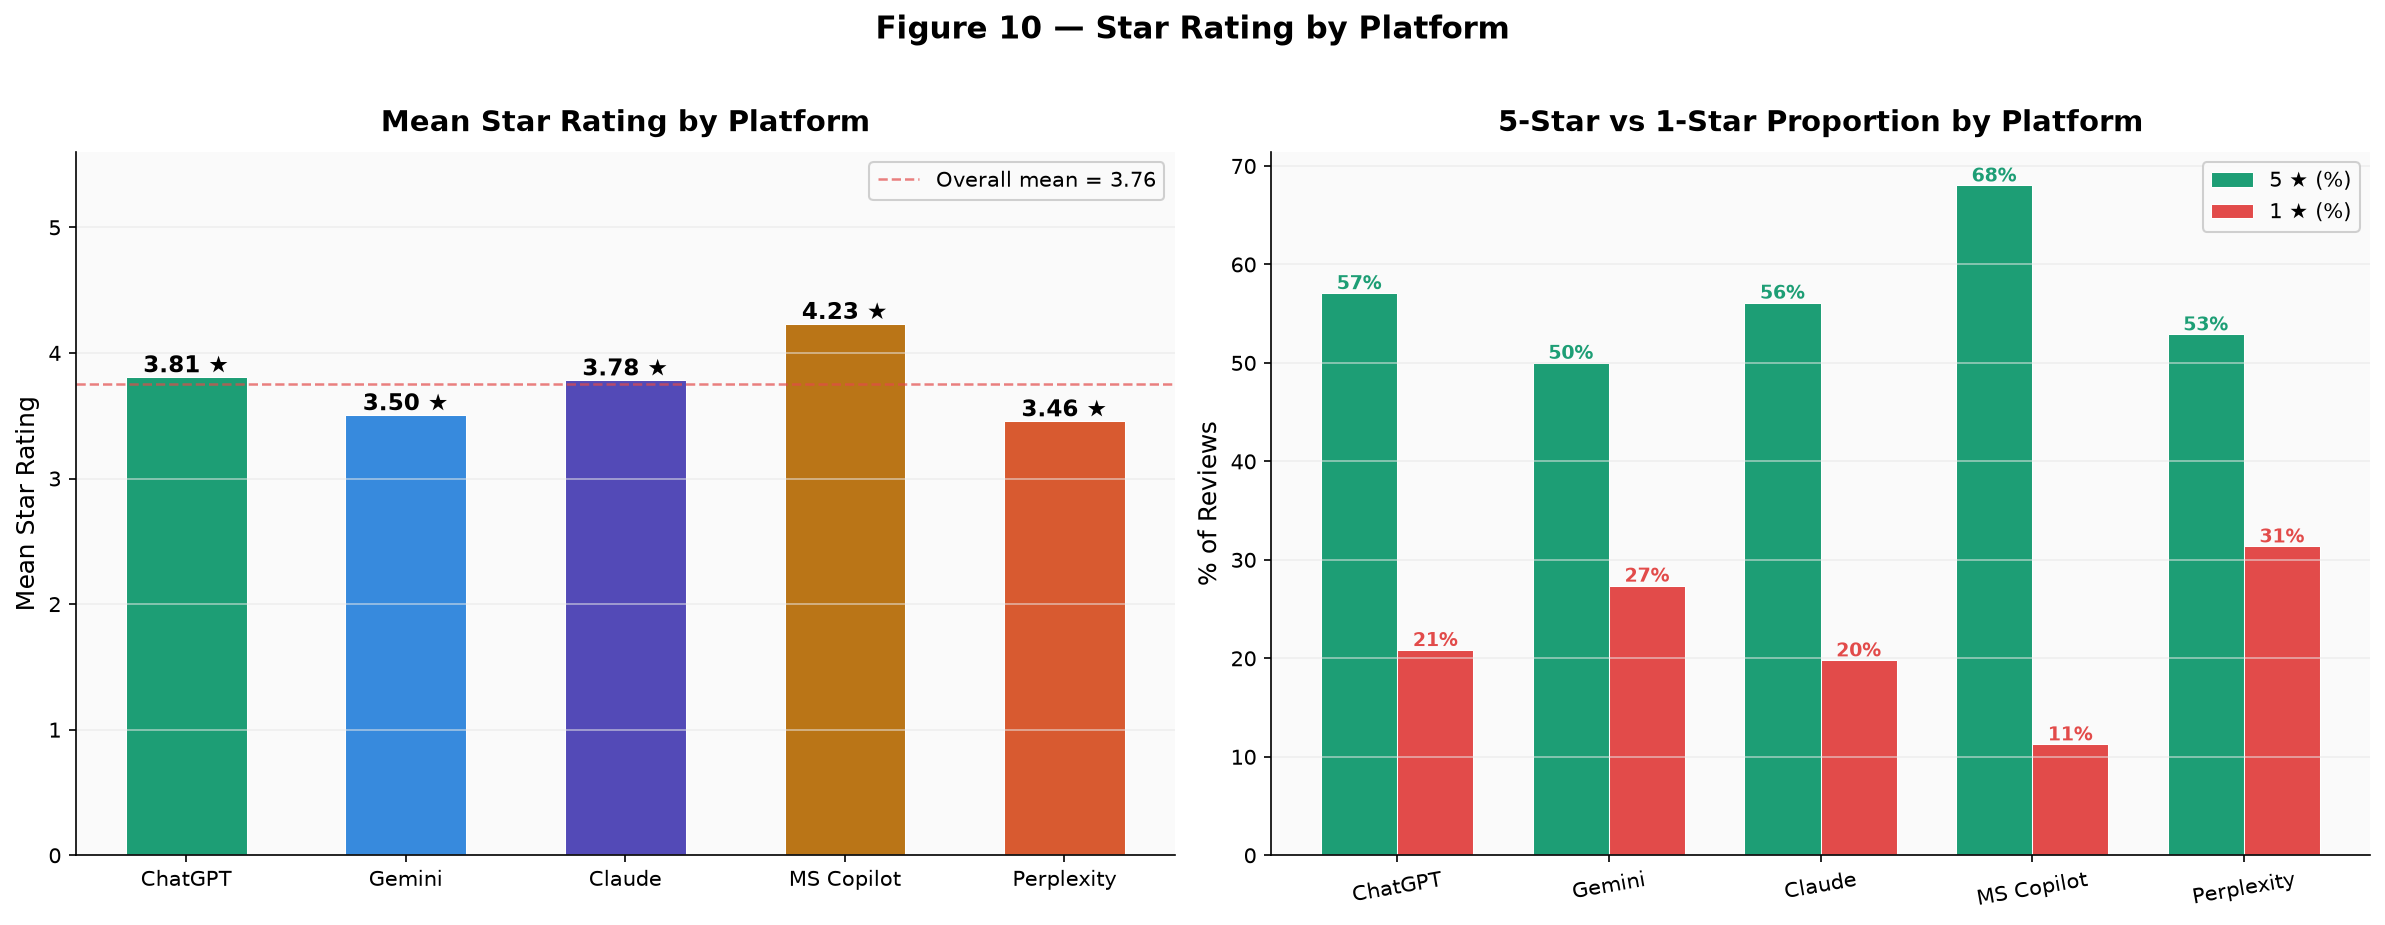

Mean star rating by platform (ranked):
  MS Copilot     : 4.231 ★
  ChatGPT        : 3.806 ★
  Claude         : 3.781 ★
  Gemini         : 3.504 ★
  Perplexity     : 3.455 ★


In [20]:
mean_stars = df.groupby("App")["Star_Rating"].mean().reindex(APP_ORDER)
pct_5star  = df[df["Star_Rating"] == 5].groupby("App").size() / 10_000 * 100
pct_1star  = df[df["Star_Rating"] == 1].groupby("App").size() / 10_000 * 100
pct_5star  = pct_5star.reindex(APP_ORDER)
pct_1star  = pct_1star.reindex(APP_ORDER)
app_display = [APP_LABELS[a] for a in APP_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: mean star rating ────────────────────────────────────────────────────
bars = axes[0].bar(
    app_display, mean_stars.values,
    color=PALETTE, edgecolor="white", linewidth=0.5, width=0.55
)
for bar, val in zip(bars, mean_stars.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.04,
        f"{val:.2f} ★", ha="center", fontsize=11, fontweight="bold"
    )
axes[0].axhline(
    df["Star_Rating"].mean(), color="#E24B4A",
    linestyle="--", linewidth=1.2, alpha=0.7,
    label=f"Overall mean = {df['Star_Rating'].mean():.2f}"
)
axes[0].set_ylabel("Mean Star Rating")
axes[0].set_ylim(0, 5.6)
axes[0].set_title("Mean Star Rating by Platform",
                  fontweight="bold", pad=10)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.6)

# ── Right: 5-star vs 1-star proportion ───────────────────────────────────────
x = np.arange(len(APP_ORDER))
w = 0.36
b5 = axes[1].bar(x - w / 2, pct_5star, width=w, color="#1D9E75",
                 label="5 ★ (%)", edgecolor="white", linewidth=0.5)
b1 = axes[1].bar(x + w / 2, pct_1star, width=w, color="#E24B4A",
                 label="1 ★ (%)", edgecolor="white", linewidth=0.5)
for bar, val in zip(b5, pct_5star):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f"{val:.0f}%", ha="center", fontsize=9,
                 color="#1D9E75", fontweight="bold")
for bar, val in zip(b1, pct_1star):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f"{val:.0f}%", ha="center", fontsize=9,
                 color="#E24B4A", fontweight="bold")
axes[1].set_xticks(x)
axes[1].set_xticklabels(app_display, rotation=10)
axes[1].set_ylabel("% of Reviews")
axes[1].set_title("5-Star vs 1-Star Proportion by Platform",
                  fontweight="bold", pad=10)
axes[1].legend(fontsize=10)
axes[1].grid(axis="y", alpha=0.6)

plt.suptitle("Figure 10 — Star Rating by Platform",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_10_star_by_platform.png")
plt.show()

print("Mean star rating by platform (ranked):")
for app, val in mean_stars.sort_values(ascending=False).items():
    print(f"  {APP_LABELS[app]:<14} : {val:.3f} ★")

### 6.2 Sentiment polarity by platform — violin plot

**Why:** A violin plot reveals the **full distribution shape** per platform, not just the mean. The width at each value represents the density of reviews, making bimodal or skewed distributions immediately visible. Inner quartile lines show the 25th, 50th, and 75th percentiles.

  📁  Saved → ../outputs/figures/fig_11_sentiment_violin.png


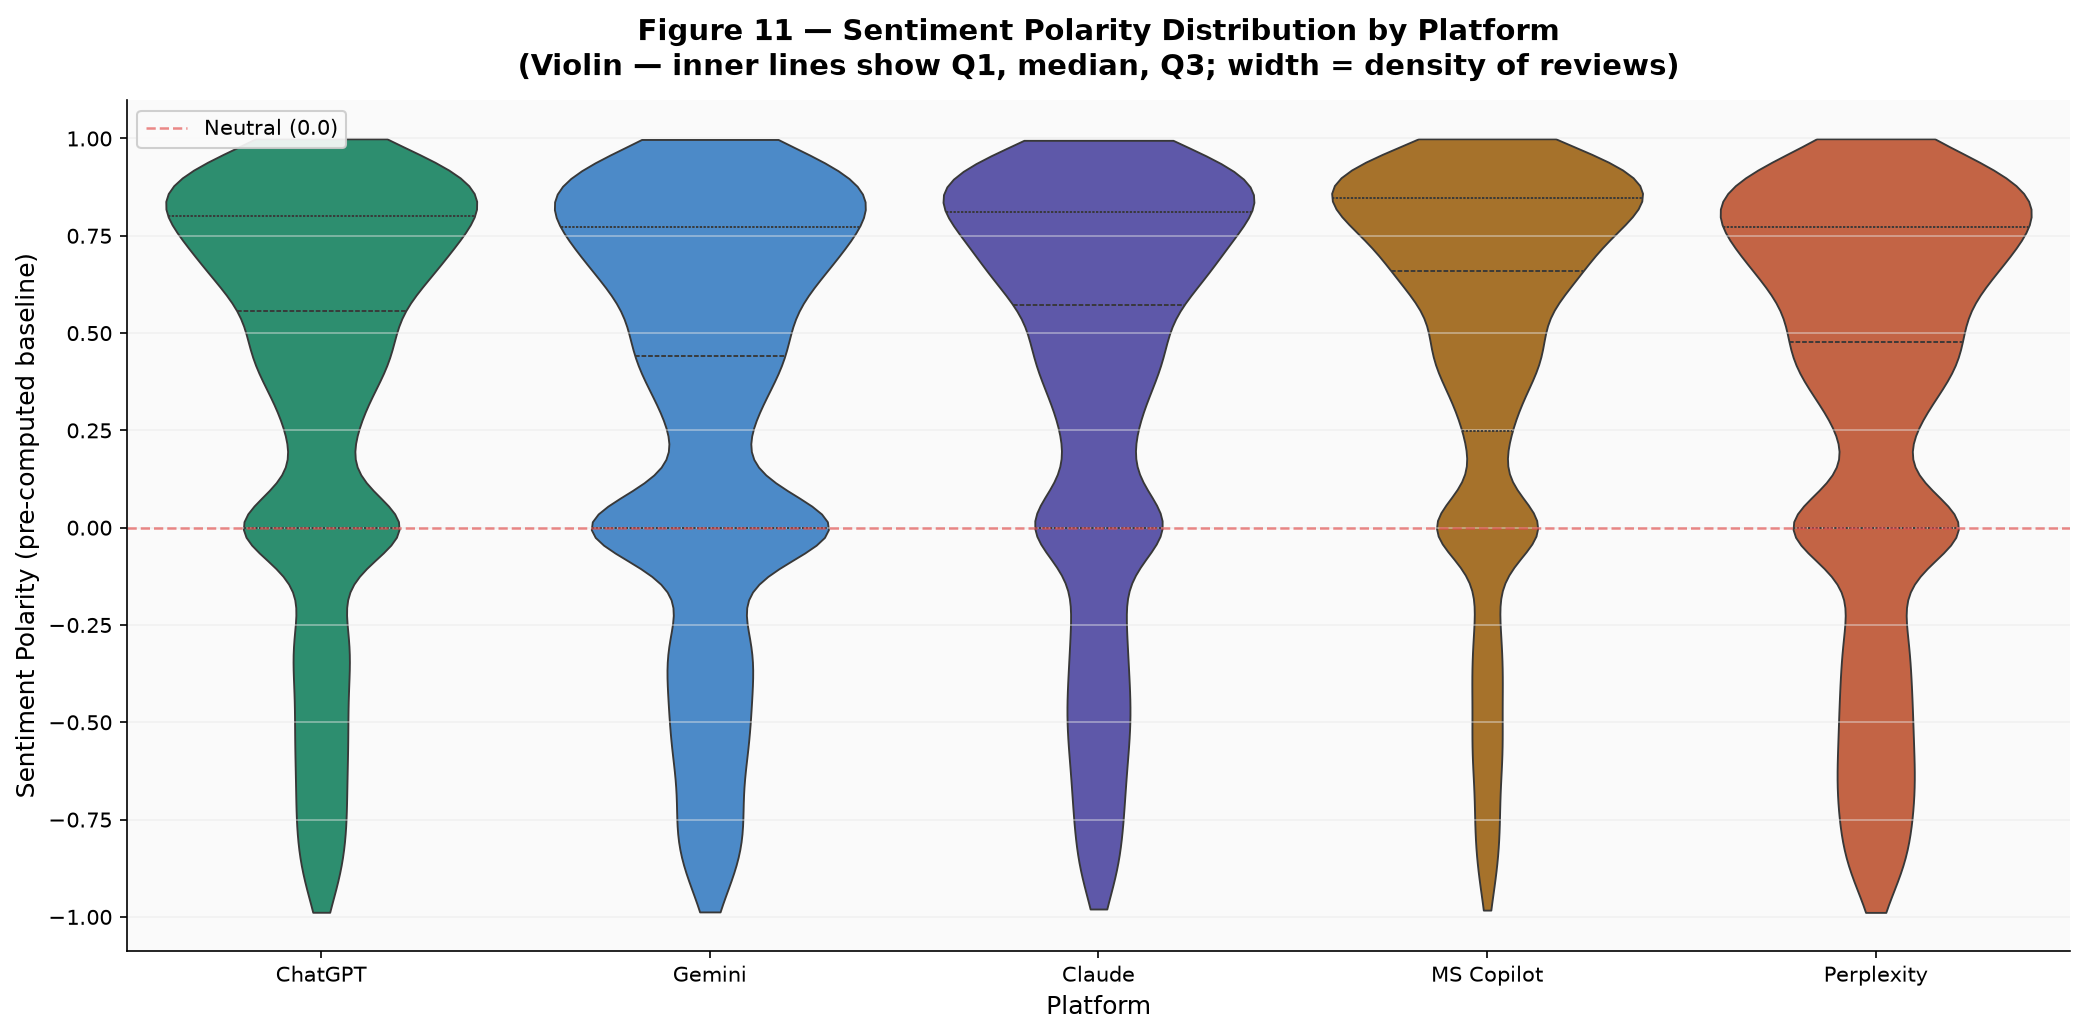

Sentiment polarity statistics:
             mean  median    std
App                             
ChatGPT    0.3697  0.5563 0.5224
Claude     0.3721  0.5719 0.5287
Gemini     0.2941  0.4404 0.5341
MS Copilot 0.4872  0.6601 0.4745
Perplexity 0.3119  0.4767 0.5412


In [21]:
df_plot = df.copy()
df_plot["Platform"] = df_plot["App"].map(APP_LABELS)
platform_order = [APP_LABELS[a] for a in APP_ORDER]

fig, ax = plt.subplots(figsize=(14, 7))
sns.violinplot(
    data=df_plot,
    x="Platform", y="Sentiment_Polarity",
    order=platform_order,
    palette=PALETTE,
    inner="quartile",
    linewidth=0.9,
    cut=0,
    ax=ax,
)
ax.axhline(0, color="#E24B4A", linestyle="--",
           linewidth=1.2, alpha=0.65, label="Neutral (0.0)")
ax.set_xlabel("Platform")
ax.set_ylabel("Sentiment Polarity (pre-computed baseline)")
ax.set_title(
    "Figure 11 — Sentiment Polarity Distribution by Platform\n"
    "(Violin — inner lines show Q1, median, Q3; width = density of reviews)",
    fontweight="bold", pad=12
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.5)

plt.tight_layout()
save_fig("fig_11_sentiment_violin.png")
plt.show()

sent_stats = (
    df.groupby("App")["Sentiment_Polarity"]
      .agg(["mean", "median", "std"])
      .round(4)
      .rename(index=APP_LABELS)
)
print("Sentiment polarity statistics:")
print(sent_stats.to_string())

### 6.3 Star rating vs. sentiment polarity

**Why:** This is the **critical validation** of the pre-computed `Sentiment_Polarity` column. If the column is meaningful, we should see a clear monotonic positive relationship between star rating and sentiment — and the Pearson *r* quantifies how strong that relationship is. A high *r* (> 0.5) validates the baseline; a low *r* signals that our RoBERTa model must fully replace it.

  📁  Saved → ../outputs/figures/fig_12_star_vs_sentiment.png


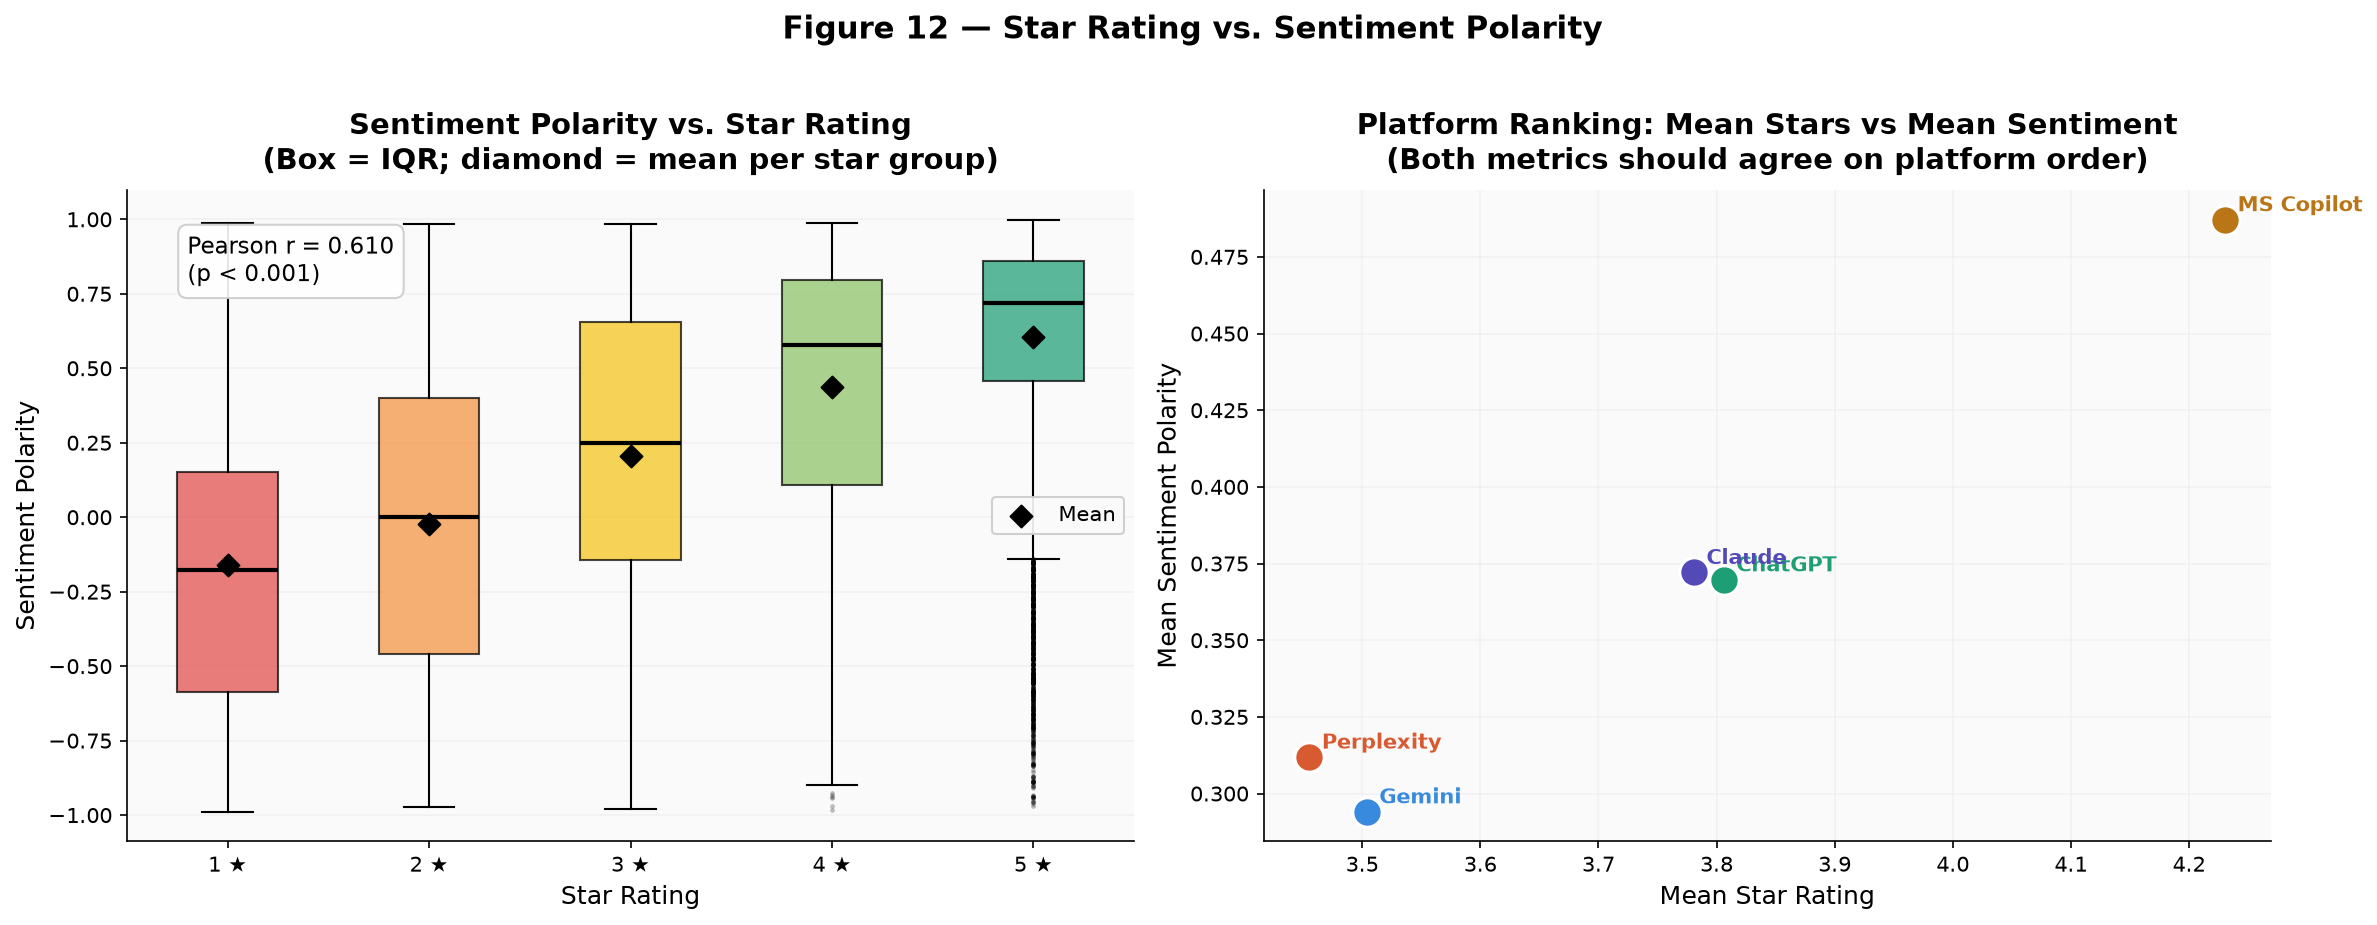

Pearson r (Star_Rating vs Sentiment_Polarity): 0.6096
p-value: < 0.001
→ Strong positive correlation — pre-computed column is broadly valid as a baseline.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left: boxplot — sentiment per star rating ──────────────────────────────────
box_data = [df[df["Star_Rating"] == s]["Sentiment_Polarity"].values
            for s in range(1, 6)]
bp = axes[0].boxplot(
    box_data, patch_artist=True,
    medianprops={"color": "black", "linewidth": 2},
    flierprops={"marker": ".", "markersize": 2.5, "alpha": 0.25}
)
for patch, color in zip(bp["boxes"], STAR_COLORS):
    patch.set_facecolor(color)
    patch.set_alpha(0.72)

means_by_star = [df[df["Star_Rating"] == s]["Sentiment_Polarity"].mean()
                 for s in range(1, 6)]
axes[0].scatter(range(1, 6), means_by_star, color="black",
                zorder=5, marker="D", s=55, label="Mean")

corr_r, corr_p = stats.pearsonr(
    df["Star_Rating"], df["Sentiment_Polarity"]
)
axes[0].annotate(
    f"Pearson r = {corr_r:.3f}\n(p < 0.001)",
    xy=(0.06, 0.86), xycoords="axes fraction", fontsize=11,
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
              edgecolor="#cccccc", alpha=0.9)
)
axes[0].set_xticks(range(1, 6))
axes[0].set_xticklabels([f"{s} ★" for s in range(1, 6)])
axes[0].set_xlabel("Star Rating")
axes[0].set_ylabel("Sentiment Polarity")
axes[0].set_title(
    "Sentiment Polarity vs. Star Rating\n(Box = IQR; diamond = mean per star group)",
    fontweight="bold", pad=10
)
axes[0].legend(fontsize=10)
axes[0].grid(axis="y", alpha=0.5)

# ── Right: platform scatter — mean stars vs mean sentiment ────────────────────
plat_stats = df.groupby("App").agg(
    MeanStars=("Star_Rating",        "mean"),
    MeanSent =("Sentiment_Polarity", "mean")
).reindex(APP_ORDER)

for app in APP_ORDER:
    row = plat_stats.loc[app]
    axes[1].scatter(row["MeanStars"], row["MeanSent"],
                    color=APP_COLORS[app], s=200, zorder=5,
                    edgecolors="white", linewidth=1.5)
    axes[1].annotate(
        APP_LABELS[app],
        xy=(row["MeanStars"], row["MeanSent"]),
        xytext=(6, 4), textcoords="offset points",
        fontsize=10, color=APP_COLORS[app], fontweight="bold"
    )

axes[1].set_xlabel("Mean Star Rating")
axes[1].set_ylabel("Mean Sentiment Polarity")
axes[1].set_title(
    "Platform Ranking: Mean Stars vs Mean Sentiment\n(Both metrics should agree on platform order)",
    fontweight="bold", pad=10
)
axes[1].grid(True, alpha=0.45)

plt.suptitle("Figure 12 — Star Rating vs. Sentiment Polarity",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("fig_12_star_vs_sentiment.png")
plt.show()

print(f"Pearson r (Star_Rating vs Sentiment_Polarity): {corr_r:.4f}")
print(f"p-value: < 0.001")
if corr_r >= 0.5:
    print("→ Strong positive correlation — pre-computed column is broadly valid as a baseline.")
else:
    print("→ Moderate correlation — RoBERTa scores will provide a more reliable signal.")

### 6.4 Review theme by platform

**Why:** Even coarse theme labels reveal platform-specific pain points. Claude's notably higher proportion of Pricing/Subscription reviews (vs. MS Copilot) is a direct, actionable insight for the final report's recommendations section.

  📁  Saved → ../outputs/figures/fig_13_theme_by_platform.png


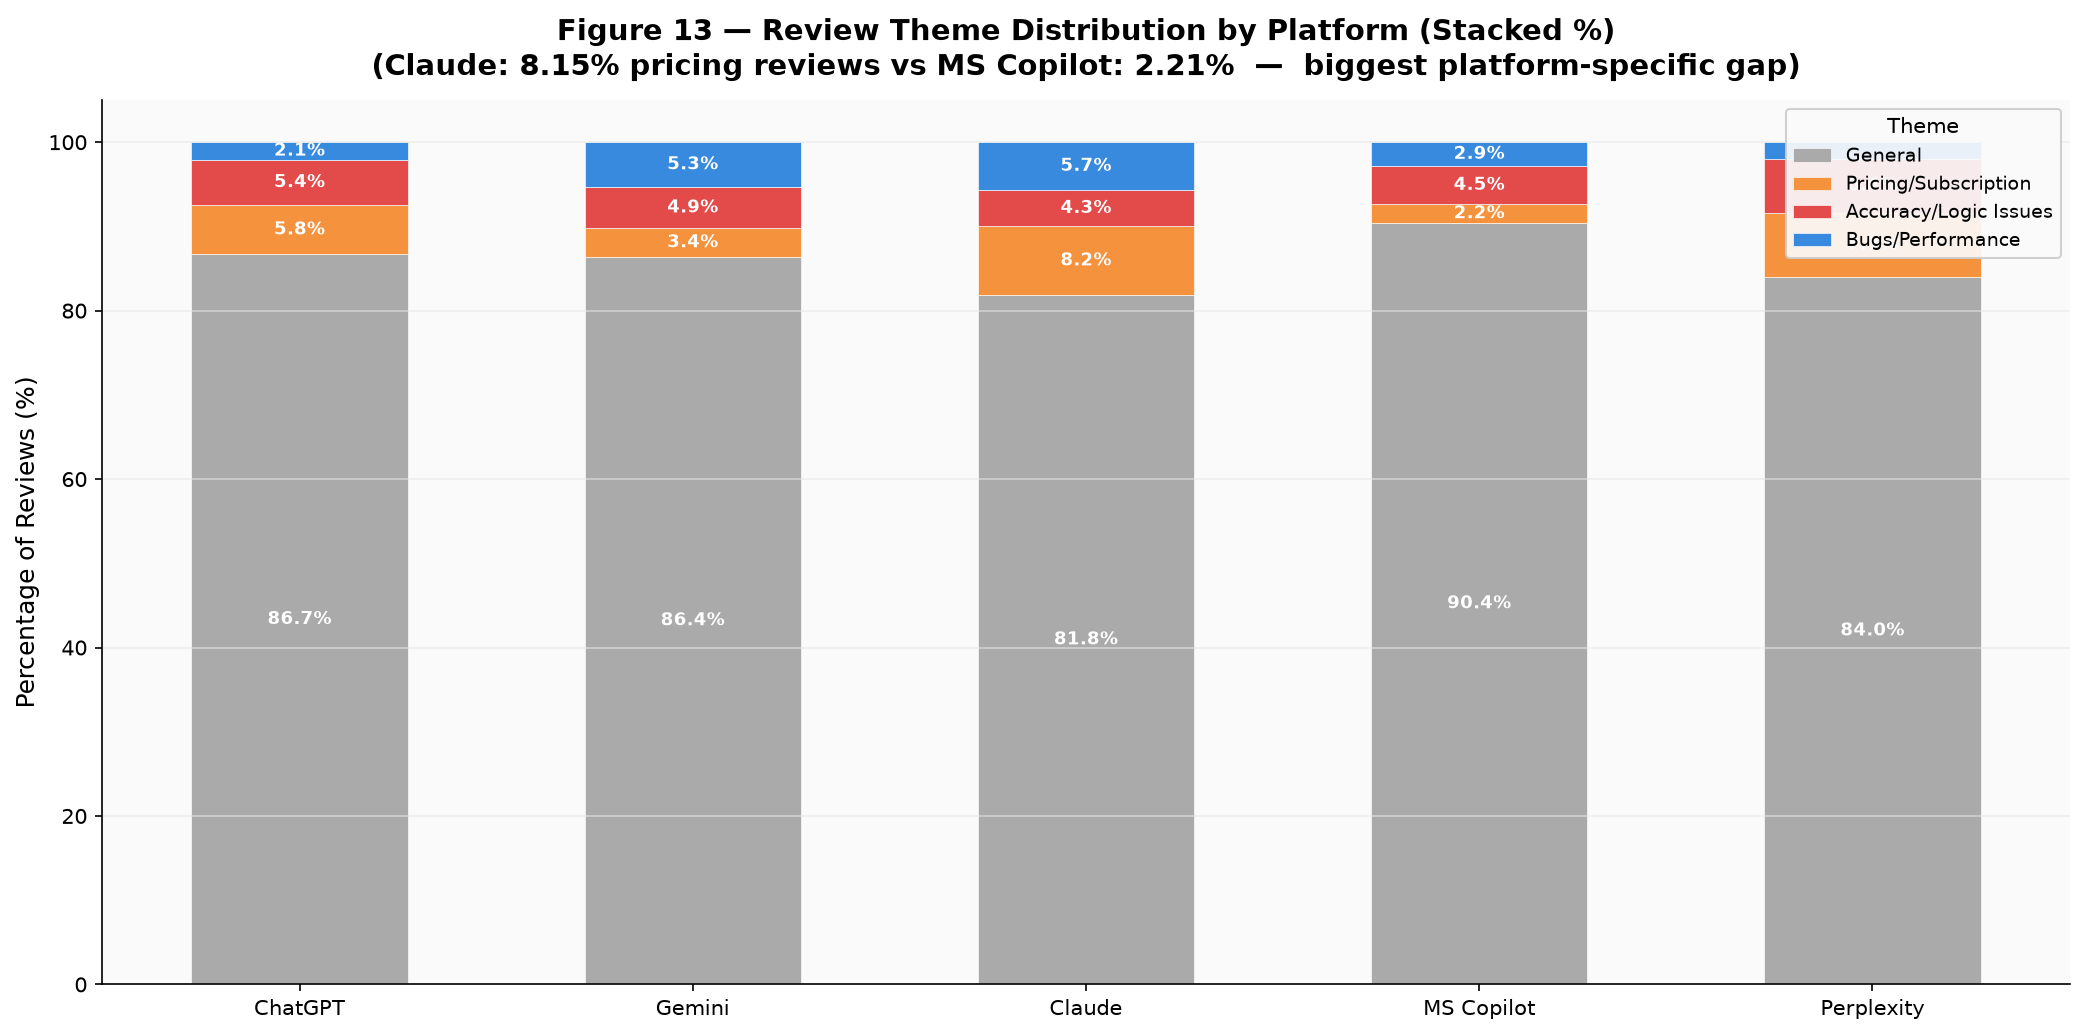

Review theme % by platform:
Review_Theme  Accuracy/Logic Issues  Bugs/Performance  General  Pricing/Subscription
ChatGPT                      5.4100            2.0800  86.6800                5.8300
Gemini                       4.9000            5.3400  86.3900                3.3700
Claude                       4.3000            5.7000  81.8500                8.1500
MS Copilot                   4.5200            2.8500  90.4200                2.2100
Perplexity                   6.4300            1.9400  83.9700                7.6600


In [23]:
theme_pct = (
    df.groupby(["App", "Review_Theme"])
      .size()
      .reset_index(name="Count")
)
theme_pct["Pct"] = (
    theme_pct.groupby("App")["Count"]
             .transform(lambda x: x / x.sum() * 100)
)

themes_order   = df["Review_Theme"].value_counts().index.tolist()
theme_pal      = ["#AAAAAA", "#F5923E", "#E24B4A", "#378ADD"]
theme_color_map = {t: c for t, c in zip(themes_order, theme_pal)}
app_display     = [APP_LABELS[a] for a in APP_ORDER]

fig, ax = plt.subplots(figsize=(14, 7))
bottom = np.zeros(len(APP_ORDER))

for theme in themes_order:
    sub = (
        theme_pct[theme_pct["Review_Theme"] == theme]
        .set_index("App")
        .reindex(APP_ORDER)
        .fillna(0)
    )
    vals  = sub["Pct"].values
    color = theme_color_map.get(theme, "#CCCCCC")
    ax.bar(app_display, vals, bottom=bottom,
           color=color, label=theme,
           edgecolor="white", linewidth=0.3, width=0.55)
    for i, (val, bot) in enumerate(zip(vals, bottom)):
        if val > 2.0:
            ax.text(
                i, bot + val / 2,
                f"{val:.1f}%", ha="center", va="center",
                fontsize=8.5, fontweight="bold", color="white"
            )
    bottom += vals

ax.set_ylabel("Percentage of Reviews (%)")
ax.set_title(
    "Figure 13 — Review Theme Distribution by Platform (Stacked %)\n"
    "(Claude: 8.15% pricing reviews vs MS Copilot: 2.21%  —  biggest platform-specific gap)",
    fontweight="bold", pad=12
)
ax.legend(title="Theme", loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.6)

plt.tight_layout()
save_fig("fig_13_theme_by_platform.png")
plt.show()

pivot_print = (
    theme_pct.pivot(index="App", columns="Review_Theme", values="Pct")
             .fillna(0)
             .reindex(APP_ORDER)
             .round(2)
)
pivot_print.index = [APP_LABELS[a] for a in APP_ORDER]
print("Review theme % by platform:")
print(pivot_print.to_string())

---
## 🌡️ Section 7 — Numerical Correlation Matrix

**Why:** The heatmap reveals all pairwise linear relationships between numerical features in a single chart. It guides feature selection for the ML classifier in Notebook 06 and flags any redundant columns. We show only the lower triangle to avoid visual duplication.

  📁  Saved → ../outputs/figures/fig_14_correlation_heatmap.png


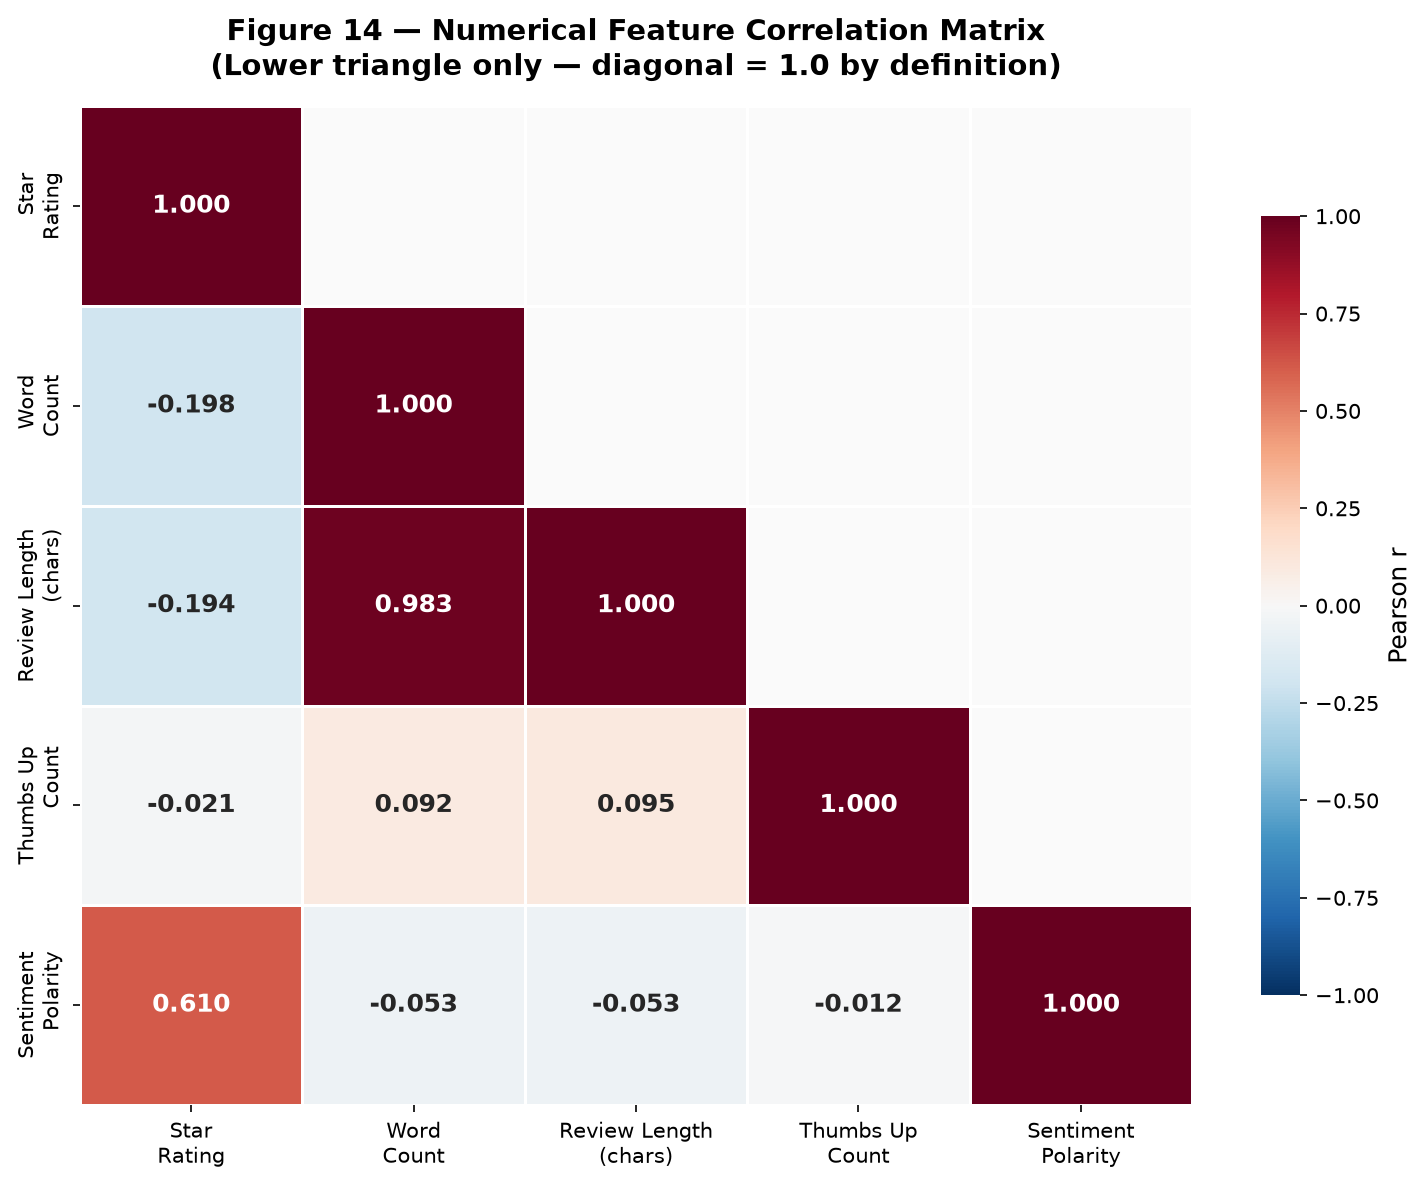

Notable correlations (|r| > 0.15):
  Star_Rating  ↔  Word_Count
    r = -0.1978  (negative)
  Star_Rating  ↔  Review_Length_Chars
    r = -0.1938  (negative)
  Star_Rating  ↔  Sentiment_Polarity
    r = 0.6096  (positive)
  Word_Count  ↔  Review_Length_Chars
    r = 0.9830  (positive)


In [24]:
num_cols_corr = [
    "Star_Rating", "Word_Count", "Review_Length_Chars",
    "Thumbs_Up_Count", "Sentiment_Polarity"
]
corr_matrix = df[num_cols_corr].corr()

nice_labels = {
    "Star_Rating"         : "Star\nRating",
    "Word_Count"          : "Word\nCount",
    "Review_Length_Chars" : "Review Length\n(chars)",
    "Thumbs_Up_Count"     : "Thumbs Up\nCount",
    "Sentiment_Polarity"  : "Sentiment\nPolarity",
}
corr_display = corr_matrix.rename(index=nice_labels, columns=nice_labels)

# Lower-triangle mask
mask = np.triu(np.ones_like(corr_display, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr_display, ax=ax, mask=mask,
    annot=True, fmt=".3f", annot_kws={"size": 12, "weight": "bold"},
    cmap="RdBu_r", vmin=-1, vmax=1, center=0,
    linewidths=0.6, linecolor="white",
    cbar_kws={"shrink": 0.78, "label": "Pearson r"}
)
ax.set_title(
    "Figure 14 — Numerical Feature Correlation Matrix\n"
    "(Lower triangle only — diagonal = 1.0 by definition)",
    fontweight="bold", pad=15
)
ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()
save_fig("fig_14_correlation_heatmap.png")
plt.show()

print("Notable correlations (|r| > 0.15):")
for i, c1 in enumerate(num_cols_corr):
    for j, c2 in enumerate(num_cols_corr):
        if j > i:
            r = corr_matrix.loc[c1, c2]
            if abs(r) > 0.15:
                direction = "positive" if r > 0 else "negative"
                print(f"  {c1}  ↔  {c2}")
                print(f"    r = {r:.4f}  ({direction})")

---
## 📋 Section 8 — EDA Summary & Key Findings

This section synthesises every finding from the notebook into a structured scorecard. These findings are directly referenced in the methodology sections of Notebooks 02–05 and the final report.

In [25]:
print("=" * 70)
print("  EDA SCORECARD — SENTIMENTCOMPASS  (50K GENAI USER REVIEWS)")
print("=" * 70)

print()
print("── 1. DATASET STRUCTURE ─────────────────────────────────────────────────")
print(f"  Rows             : {len(df):>10,}")
print(f"  Columns          : {df.shape[1]:>10}")
print(f"  Platforms        : {df['App'].nunique()}  (10,000 each — perfectly balanced)")
print(f"  Date range       : {df['Review_Date'].min().date()}  →  {df['Review_Date'].max().date()}")

print()
print("── 2. DATA QUALITY AUDIT ────────────────────────────────────────────────")
print(f"  Exact duplicates            : {df.duplicated().sum()}")
print(f"  Duplicate Review_Text       : {df['Review_Text'].duplicated().sum()} rows")
print(f"  App_Version missing         : {df['App_Version'].isnull().sum():,}  ({df['App_Version'].isnull().mean()*100:.1f}%)")
print(f"  Truncated reviews ('...')   : {df['Review_Text'].str.strip().str.endswith('...').sum():,}")
print(f"  Non-ASCII reviews           : {df['Review_Text'].apply(lambda x: any(ord(c)>127 for c in str(x))).sum():,}  ({df['Review_Text'].apply(lambda x: any(ord(c)>127 for c in str(x))).mean()*100:.1f}%)")
print(f"  Sentiment_Polarity == 0.0   : {(df['Sentiment_Polarity']==0.0).sum():,}  ({(df['Sentiment_Polarity']==0.0).mean()*100:.1f}%)")

print()
print("── 3. STAR RATINGS ──────────────────────────────────────────────────────")
ms = df.groupby("App")["Star_Rating"].mean().reindex(APP_ORDER)
print(f"  Overall mean     : {df['Star_Rating'].mean():.3f}")
print(f"  5-star reviews   : {(df['Star_Rating']==5).sum():,}  ({(df['Star_Rating']==5).mean()*100:.1f}%)  ← J-curve dominant")
print(f"  1-star reviews   : {(df['Star_Rating']==1).sum():,}  ({(df['Star_Rating']==1).mean()*100:.1f}%)")
print(f"  Highest rated    : {APP_LABELS[ms.idxmax()]}  ({ms.max():.3f} ★)")
print(f"  Lowest rated     : {APP_LABELS[ms.idxmin()]}  ({ms.min():.3f} ★)")

print()
print("── 4. TEMPORAL IMBALANCE  ⚠  CRITICAL ──────────────────────────────────")
for app in APP_ORDER:
    sub  = df[df["App"] == app]["Review_Date"]
    days = (sub.max() - sub.min()).days
    mar  = df[(df["App"] == app) & (df["Review_Date"].dt.month == 3)].shape[0]
    print(f"  {APP_LABELS[app]:<14} : {days:>4} day window  |  {mar:,} reviews in March 2026")
total_mar = df[df["Review_Date"].dt.month == 3].shape[0]
print(f"  Total March 2026 : {total_mar:,}  ({total_mar/len(df)*100:.1f}% of ALL reviews)")

print()
print("── 5. ENGAGEMENT (THUMBS-UP) ────────────────────────────────────────────")
print(f"  Zero thumbs          : {(df['Thumbs_Up_Count']==0).sum():,}  ({(df['Thumbs_Up_Count']==0).mean()*100:.1f}%)")
print(f"  Max on single review : {df['Thumbs_Up_Count'].max():,}")
print(f"  Reviews > 100 thumbs : {(df['Thumbs_Up_Count']>100).sum():,}")

print()
print("── 6. REVIEW THEME ──────────────────────────────────────────────────────")
tc = df["Review_Theme"].value_counts()
for theme, cnt in tc.items():
    print(f"  {theme:<30} : {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

print()
print("── 7. IMPLICATIONS FOR DOWNSTREAM NOTEBOOKS ────────────────────────────")
print()
implications = [
    ("NB02 Cleaning",    "Unicode normalise; impute App_Version='Unknown'; expand contractions"),
    ("NB02 Features",    "Add: month, year, sentiment_gap (star - norm_sent), is_influential"),
    ("NB03 Sentiment",   "Recompute ALL scores — VADER + TextBlob + RoBERTa; compute TWSI"),
    ("NB03 Sentiment",   "Do NOT rely solely on Sentiment_Polarity (10.1% are exactly 0.0)"),
    ("NB04 Topics",      "Review_Theme too coarse (85.9% = General) — run LDA + BERTopic"),
    ("NB05 Migration",   "Use NER to detect competitor mentions across all 50K reviews"),
    ("Dashboard",        "Time-series charts must restrict to March 2026 for cross-platform"),
    ("ML Classifier",    "Use class_weight='balanced' — J-shaped star distribution"),
]
for nb_name, note in implications:
    print(f"  [{nb_name:<18}] {note}")

print()
print(f"✅  EDA complete. 14 figures saved to: {os.path.abspath(FIGURES_DIR)}")
print("▶   Next: run 02_preprocessing.ipynb")

  EDA SCORECARD — SENTIMENTCOMPASS  (50K GENAI USER REVIEWS)

── 1. DATASET STRUCTURE ─────────────────────────────────────────────────
  Rows             :     50,000
  Columns          :         10
  Platforms        : 5  (10,000 each — perfectly balanced)
  Date range       : 2025-05-13  →  2026-03-31

── 2. DATA QUALITY AUDIT ────────────────────────────────────────────────
  Exact duplicates            : 0
  Duplicate Review_Text       : 9 rows
  App_Version missing         : 6,912  (13.8%)
  Truncated reviews ('...')   : 622
  Non-ASCII reviews           : 8,594  (17.2%)
  Sentiment_Polarity == 0.0   : 5,051  (10.1%)

── 3. STAR RATINGS ──────────────────────────────────────────────────────
  Overall mean     : 3.755
  5-star reviews   : 28,414  (56.8%)  ← J-curve dominant
  1-star reviews   : 11,068  (22.1%)
  Highest rated    : MS Copilot  (4.231 ★)
  Lowest rated     : Perplexity  (3.455 ★)

── 4. TEMPORAL IMBALANCE  ⚠  CRITICAL ──────────────────────────────────
  ChatGPT    

---

## 📌 Next steps

| EDA finding | Action in next notebook |
|---|---|
| App_Version 13.8% missing | Impute `'Unknown'` → `02_preprocessing.ipynb` |
| 17.2% non-ASCII characters | Unicode normalise → `02_preprocessing.ipynb` |
| Unequal temporal windows | Restrict time-series to March 2026 in Dashboard |
| Sentiment_Polarity 10.1% = 0.0 | Recompute all scores with RoBERTa → `03_sentiment_analysis.ipynb` |
| Review_Theme 85.9% = "General" | LDA + BERTopic → `04_topic_modeling.ipynb` |
| Thumbs_Up 76.3% = 0 | Use `log(1+x)` for TWSI → `03_sentiment_analysis.ipynb` |
| J-shaped star distribution | Use `class_weight='balanced'` in any classifier |

**▶ Proceed to `02_preprocessing.ipynb` — Data Cleaning & Feature Engineering**